<a href="https://colab.research.google.com/github/Insight-Syndicate/DSPL_GCW/blob/main/Exploration%20and%20Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Test CSV**

## **Data Exploration**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Original URL from Google Drive
url = 'https://drive.google.com/file/d/1W-_D-zk_CZeXFBDLwtbelSTgybtjpWv5/view?usp=drive_link'

# Extract the file ID
file_id = url.split('/')[-2]

# Construct the direct file access URL
file_url = 'https://drive.google.com/uc?id=' + file_id

test = pd.read_csv(file_url)
test


,Customer_ID,outlet_city,luxury_sales,fresh_sales,dry_sales
0,33574,batticaloa,2686.5,3582,12537
1,10089,batticaloa,1717.56,2576.34,9446.58
2,38329,batticaloa,854.04,1242.24,5201.88
3,11376,batticaloa,1638.12,2320.67,9282.68
4,12410,batticaloa,1039.09,1518.67,5435.24
...,...,...,...,...,...
40744,33698,Wattala,3916.48,4161.26,3916.48
40745,4185,Wattala,3191.92,3004.16,3098.04
40746,28664,Wattala,3838.6,3951.5,Three Thousand seven hundread ruppees
40747,11874,Wattala,4313.76,4183.04,4313.76


In [3]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40749 entries, 0 to 40748
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Customer_ID   40749 non-null  int64 
 1   outlet_city   40749 non-null  object
 2   luxury_sales  40749 non-null  object
 3   fresh_sales   40749 non-null  object
 4   dry_sales     40749 non-null  object
dtypes: int64(1), object(4)
memory usage: 1.6+ MB


In [4]:
test.describe()

,Customer_ID
count,40749.000000
mean,20375.000000
std,11763.367396
min,1.000000
25%,10188.000000
50%,20375.000000
75%,30562.000000
max,40749.000000


In [5]:
test.shape

(40749, 5)

In [6]:
unique_values_test = test.apply(pd.Series.unique)
print(unique_values_test)

Customer_ID     [33574, 10089, 38329, 11376, 12410, 826, 10364...
outlet_city     [batticaloa, Batticaloa, Colombo, Dehiwala-Mou...
luxury_sales    [2686.5, 1717.56, 854.04, 1638.12, 1039.09, 12...
fresh_sales     [3582, 2576.34, 1242.24, 2320.67, 1518.67, 149...
dry_sales       [12537, 9446.58, 5201.88, 9282.68, 5435.24, 68...
dtype: object


In [7]:
missing_values = test.isnull().sum()
print(missing_values)

Customer_ID     0
outlet_city     0
luxury_sales    0
fresh_sales     0
dry_sales       0
dtype: int64


In [8]:
num_duplicates1 = test.duplicated().sum()
num_duplicates1

0

## **EDA Before Cleaning**

### **UNIVARIATE**

In [9]:
# Import libraries
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

test_before = test.copy()

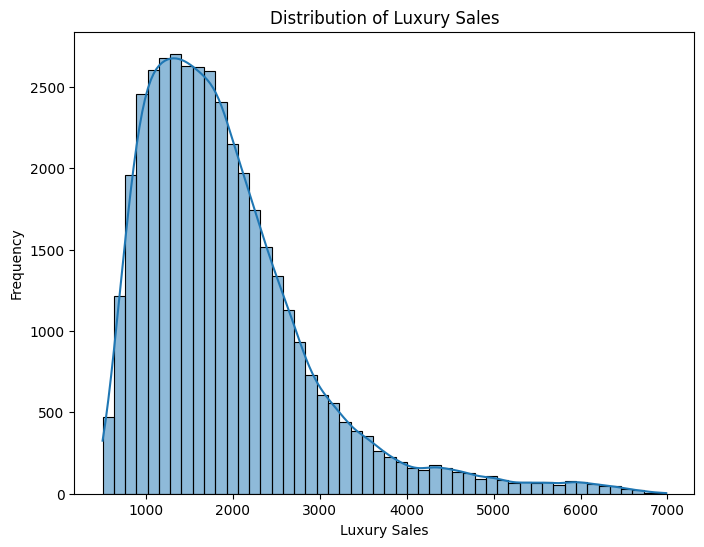

In [10]:
# Bar Plot - distribution of outlet cities
test_before['luxury_sales'] = pd.to_numeric(test_before['luxury_sales'], errors='coerce').astype(float)

plt.figure(figsize=(8, 6))
sns.histplot(test_before['luxury_sales'], bins=50, kde=True)
plt.title("Distribution of Luxury Sales")
plt.xlabel("Luxury Sales")
plt.ylabel("Frequency")
plt.show()

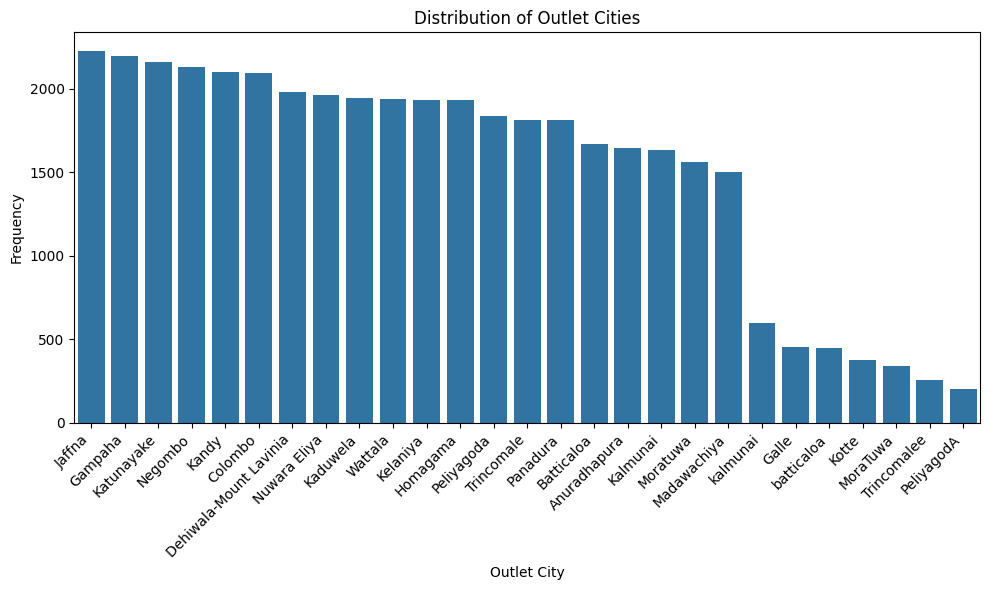

In [11]:
# Bar Plot - distribution of outlet cities

plt.figure(figsize=(10, 6))
sns.countplot(x='outlet_city', data=test_before, order=test_before['outlet_city'].value_counts().index)
plt.title('Distribution of Outlet Cities')
plt.xlabel('Outlet City')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

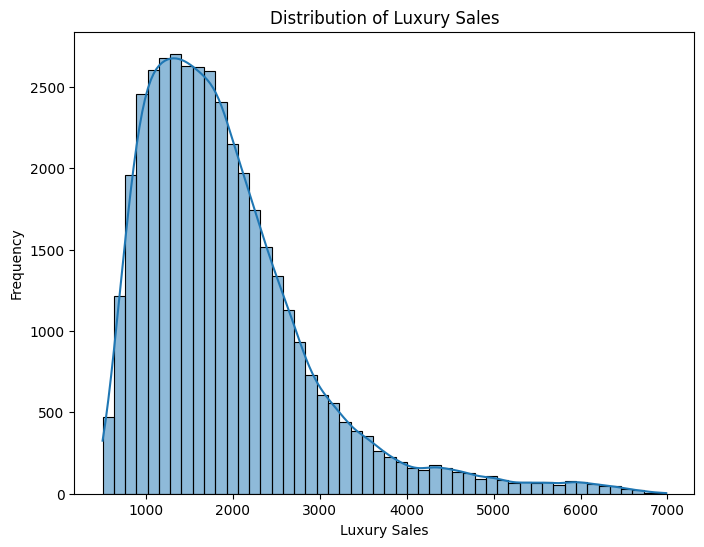

In [12]:
# distribution of luxury sales
test['luxury_sales'] = pd.to_numeric(test_before['luxury_sales'], errors='coerce').astype(float)


plt.figure(figsize=(8, 6))
sns.histplot(test_before["luxury_sales"], bins=50, kde=True)
plt.title("Distribution of Luxury Sales")
plt.xlabel("Luxury Sales")
plt.ylabel("Frequency")
plt.show()

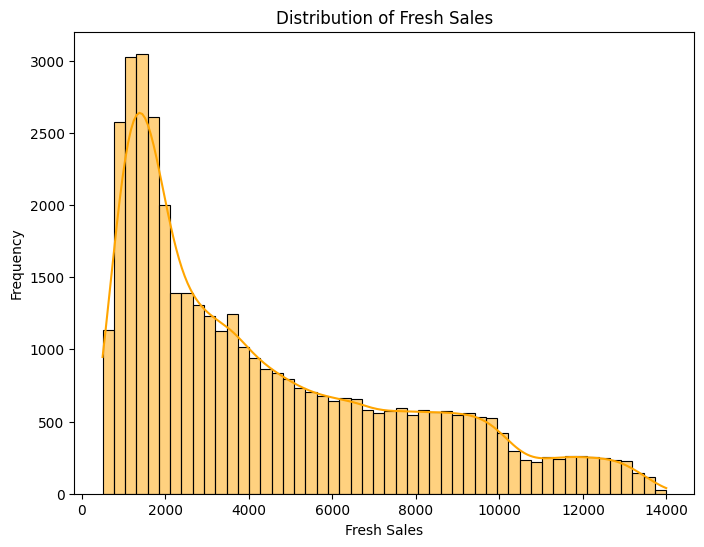

In [13]:
# distribution of fresh sales
test_before['fresh_sales'] = pd.to_numeric(test_before['fresh_sales'], errors='coerce').astype(float)

plt.figure(figsize=(8, 6))
sns.histplot(test_before['fresh_sales'], bins=50, kde=True, color='orange')
plt.title("Distribution of Fresh Sales")
plt.xlabel("Fresh Sales")
plt.ylabel("Frequency")
plt.show()

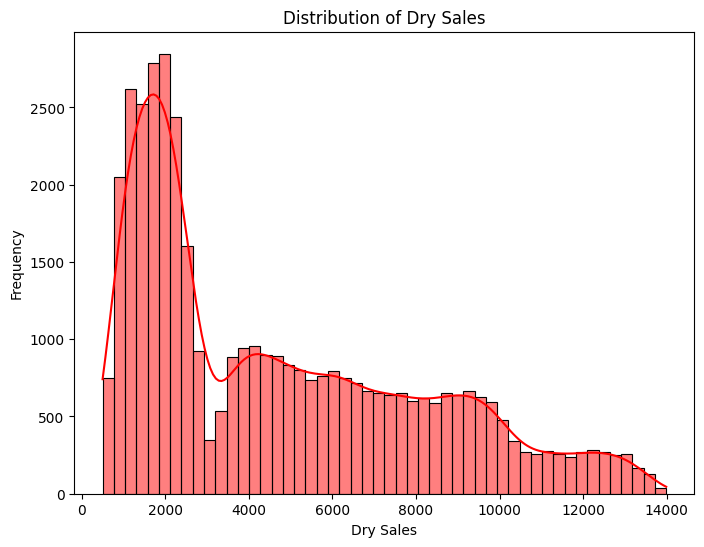

In [14]:
# distribution of dry sales
test_before['dry_sales'] = pd.to_numeric(test_before['dry_sales'], errors='coerce').astype(float)

plt.figure(figsize=(8, 6))
sns.histplot(test_before['dry_sales'], bins=50, kde=True, color='red')
plt.title("Distribution of Dry Sales")
plt.xlabel("Dry Sales")
plt.ylabel("Frequency")
plt.show()

### **MULTIVARIATE**

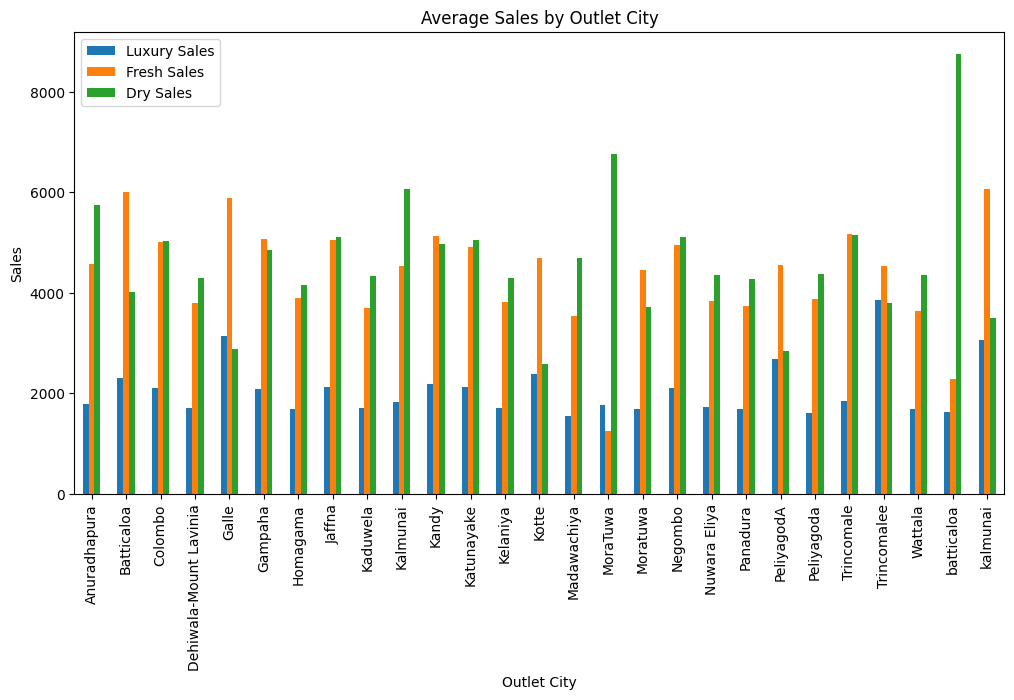

In [15]:
# Avg sales by outlet city
test_grouped = test_before.groupby("outlet_city")[["luxury_sales", "fresh_sales", "dry_sales"]].mean(numeric_only=True).reset_index()
test_grouped.plot(x="outlet_city", kind="bar", figsize=(12,6))
plt.title("Average Sales by Outlet City")
plt.xlabel("Outlet City")
plt.ylabel("Sales")
plt.xticks(rotation=90)
plt.legend(["Luxury Sales", "Fresh Sales", "Dry Sales"])
plt.show()

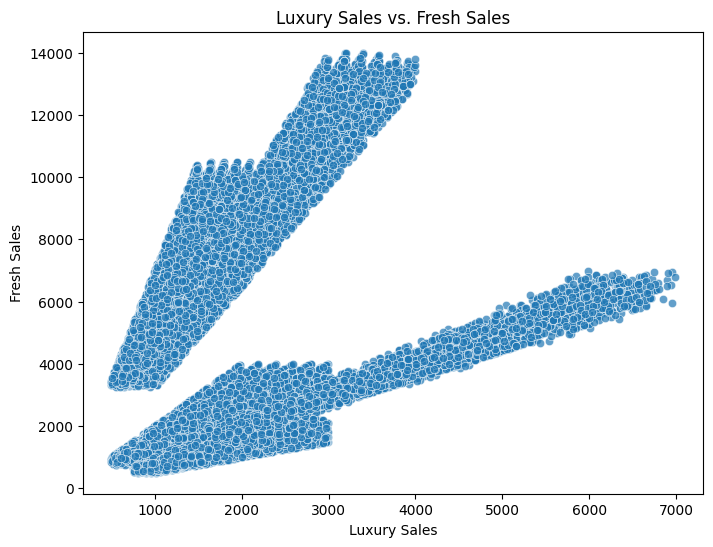

In [16]:
# scatter plot of luxury sales Vs Fresh sales
plt.figure(figsize=(8, 6))
sns.scatterplot(data=test_before, x="luxury_sales", y="fresh_sales", alpha=0.7)
plt.title("Luxury Sales vs. Fresh Sales")
plt.xlabel("Luxury Sales")
plt.ylabel("Fresh Sales")
plt.show()

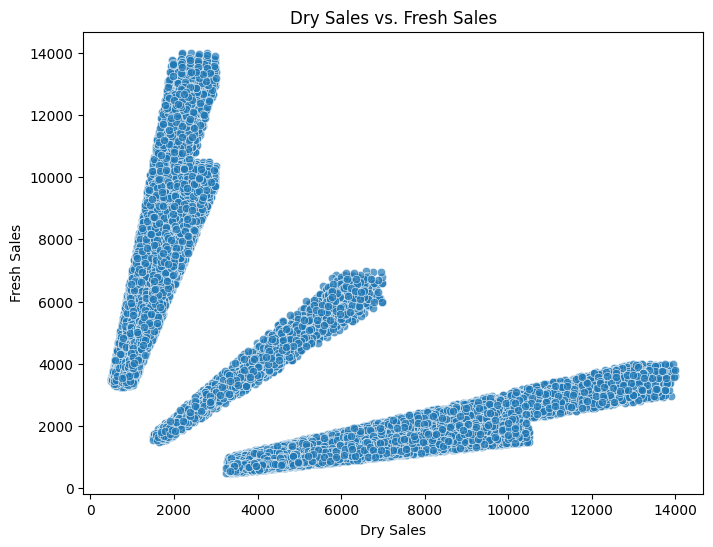

In [17]:
# Scatter plot of dry sales Vs Fresh sales
plt.figure(figsize=(8, 6))
sns.scatterplot(data=test_before, x="dry_sales", y="fresh_sales", alpha=0.7)
plt.title("Dry Sales vs. Fresh Sales")
plt.xlabel("Dry Sales")
plt.ylabel("Fresh Sales")
plt.show()

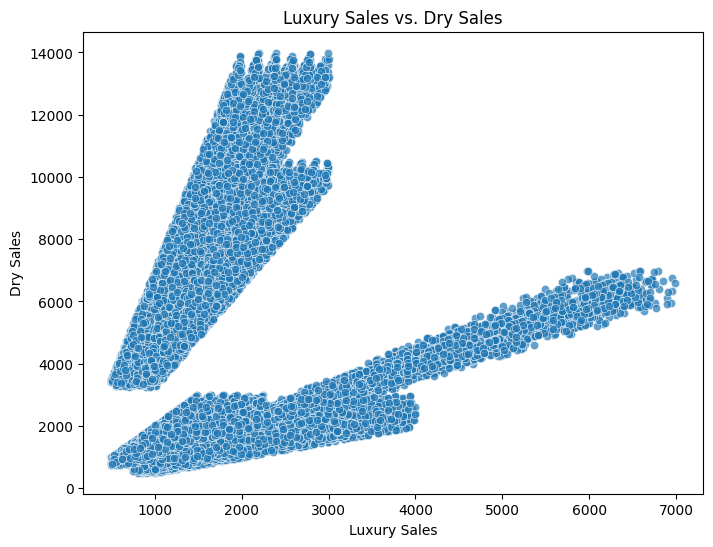

In [18]:
# scatter plot of luxury sales vs dry sales
plt.figure(figsize=(8, 6))
sns.scatterplot(data=test_before, x="luxury_sales", y="dry_sales", alpha=0.7)
plt.title("Luxury Sales vs. Dry Sales")
plt.xlabel("Luxury Sales")
plt.ylabel("Dry Sales")
plt.show()

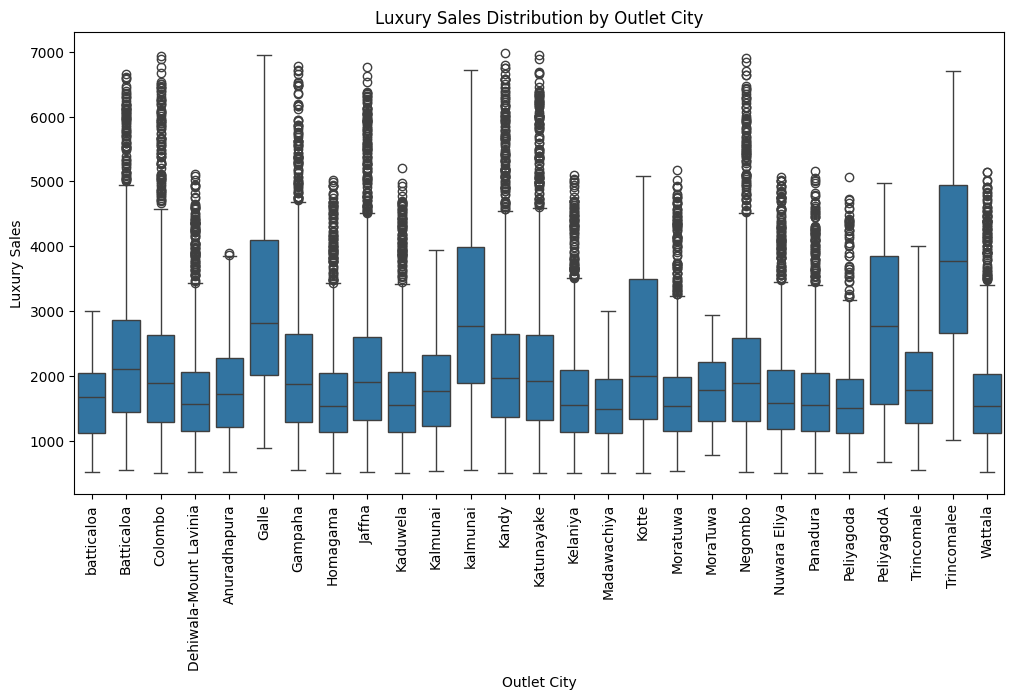

In [19]:
# luxury sales distribution by outlet city
plt.figure(figsize=(12, 6))
sns.boxplot(x="outlet_city", y="luxury_sales", data=test_before)
plt.xlabel("Outlet City")
plt.ylabel("Luxury Sales")
plt.xticks(rotation=90)
plt.title("Luxury Sales Distribution by Outlet City")
plt.show()

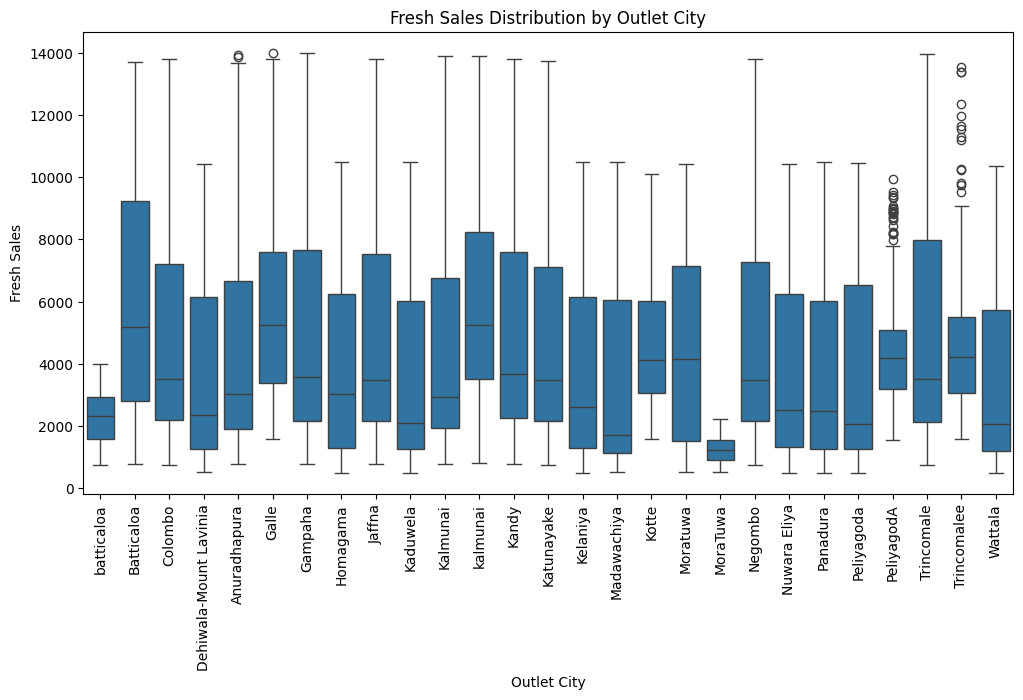

In [20]:
# fresh sales distribution by outlet city
plt.figure(figsize=(12, 6))
sns.boxplot(x="outlet_city", y="fresh_sales", data=test_before)
plt.xlabel("Outlet City")
plt.ylabel("Fresh Sales")
plt.xticks(rotation=90)
plt.title("Fresh Sales Distribution by Outlet City")
plt.show()

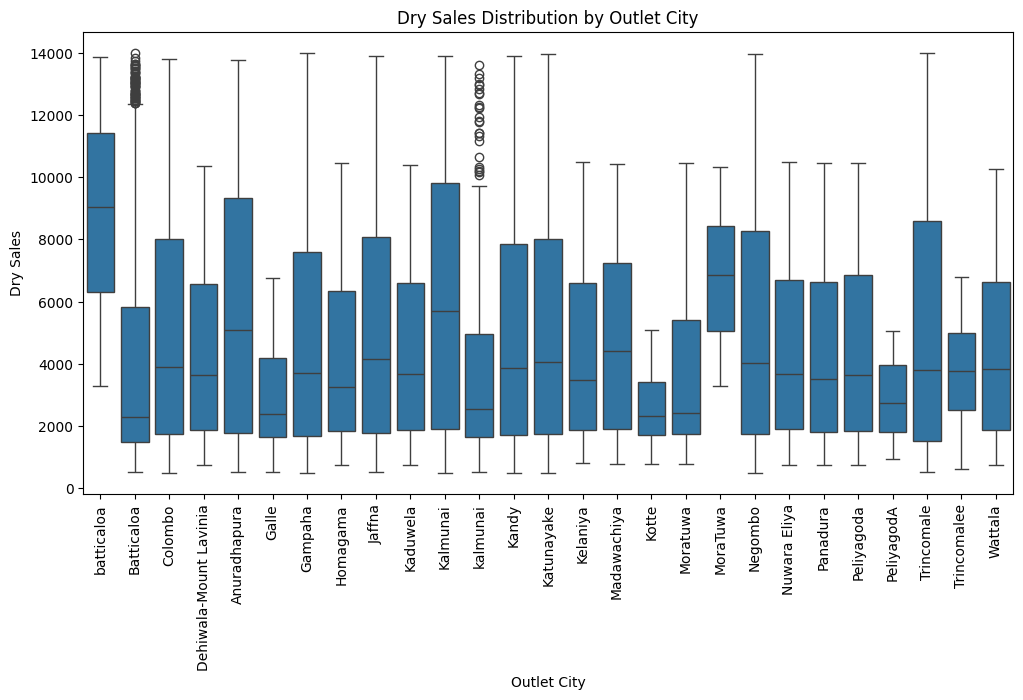

In [21]:
# dry sales distribution by outlet city
plt.figure(figsize=(12, 6))
sns.boxplot(x="outlet_city", y="dry_sales", data=test_before)
plt.xlabel("Outlet City")
plt.ylabel("Dry Sales")
plt.xticks(rotation=90)
plt.title("Dry Sales Distribution by Outlet City")
plt.show()

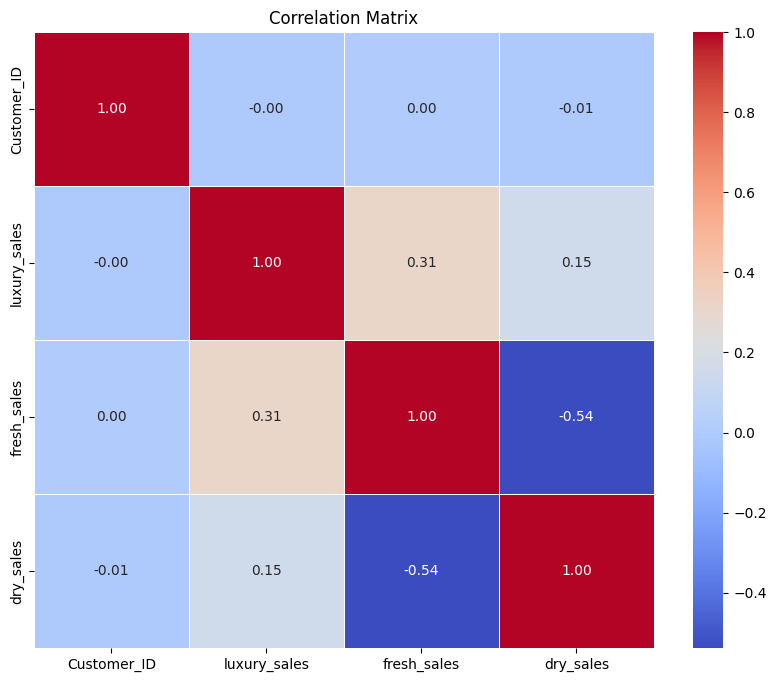

In [22]:
# correlation matrix
correlation_matrix = test_before.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix')
plt.show()

## **Data Cleaning**

In [23]:
# Original URL from Google Drive
url = 'https://drive.google.com/file/d/1W-_D-zk_CZeXFBDLwtbelSTgybtjpWv5/view?usp=drive_link'

# Extract the file ID
file_id = url.split('/')[-2]

# Construct the direct file access URL
file_url = 'https://drive.google.com/uc?id=' + file_id

# read the data again
test = pd.read_csv(file_url, dtype={'fresh_sales': str, 'luxury_sales': str, 'dry_sales': str})
test

,Customer_ID,outlet_city,luxury_sales,fresh_sales,dry_sales
0,33574,batticaloa,2686.5,3582,12537
1,10089,batticaloa,1717.56,2576.34,9446.58
2,38329,batticaloa,854.04,1242.24,5201.88
3,11376,batticaloa,1638.12,2320.67,9282.68
4,12410,batticaloa,1039.09,1518.67,5435.24
...,...,...,...,...,...
40744,33698,Wattala,3916.48,4161.26,3916.48
40745,4185,Wattala,3191.92,3004.16,3098.04
40746,28664,Wattala,3838.6,3951.5,Three Thousand seven hundread ruppees
40747,11874,Wattala,4313.76,4183.04,4313.76


In [24]:
# Check the shape of the data
test.shape

(40749, 5)

In [25]:
# Checking the datatypes
test.dtypes

,0
Customer_ID,int64
outlet_city,object
luxury_sales,object
fresh_sales,object
dry_sales,object


In [26]:
# Check for number of missing values in each coulmn
test.isnull().sum()

,0
Customer_ID,0
outlet_city,0
luxury_sales,0
fresh_sales,0
dry_sales,0


In [27]:
# change the object data types to float for sales features
test['fresh_sales'] = pd.to_numeric(test['fresh_sales'].str.replace(',', '',regex=True), errors='coerce')
test['luxury_sales'] = pd.to_numeric(test['luxury_sales'].str.replace(',', '',regex=True), errors='coerce')
test['dry_sales'] = pd.to_numeric(test['dry_sales'].str.replace(',', '',regex=True), errors='coerce')

In [28]:
# Check for number of missing values in each coulmn
test.isnull().sum()

,0
Customer_ID,0
outlet_city,0
luxury_sales,2
fresh_sales,1
dry_sales,1


In [29]:
# Total number of rows with missing values
test.isnull().any(axis=1).sum()

4

In [30]:
# display the rows with null values
test[test.isnull().any(axis=1)]

,Customer_ID,outlet_city,luxury_sales,fresh_sales,dry_sales
6,10364,batticaloa,NaN,914.40,3352.80
6299,4059,Anuradhapura,NaN,1548.69,5705.70
13949,28662,Jaffna,2195.84,NaN,1509.64
40746,28664,Wattala,3838.60,3951.50,NaN


In [31]:
# Original URL from Google Drive
url = 'https://drive.google.com/file/d/1W-_D-zk_CZeXFBDLwtbelSTgybtjpWv5/view?usp=drive_link'

# Extract the file ID
file_id = url.split('/')[-2]

# Construct the direct file access URL
file_url = 'https://drive.google.com/uc?id=' + file_id

# read the data again
test_check = pd.read_csv(file_url, dtype={'fresh_sales': str, 'luxury_sales': str, 'dry_sales': str})
test_check[test_check['Customer_ID'].isin([10364, 4059, 28662, 28664])]

,Customer_ID,outlet_city,luxury_sales,fresh_sales,dry_sales
6,10364,batticaloa,Seven Hundread and sixty Ruppees,914.4,3352.8
6299,4059,Anuradhapura,Eight Hundread and fifteen ruppes,1548.69,5705.7
13949,28662,Jaffna,2195.84,Nine thousand ruppess,1509.64
40746,28664,Wattala,3838.6,3951.5,Three Thousand seven hundread ruppees


In [32]:
# replace the values in words with the correct values
test.loc[test['Customer_ID'] == 10364, 'luxury_sales'] = 760
test.loc[test['Customer_ID'] == 4059, 'luxury_sales'] = 815
test.loc[test['Customer_ID'] == 28662, 'fresh_sales'] = 9000
test.loc[test['Customer_ID'] == 28664, 'dry_sales'] = 3700

In [33]:
# Total number of rows with missing values
test.isnull().any(axis=1).sum()

0

In [34]:
# change the customer ID feature to string datatype
test['Customer_ID'] = test['Customer_ID'].astype(str)
# Check data types
test.dtypes

,0
Customer_ID,object
outlet_city,object
luxury_sales,float64
fresh_sales,float64
dry_sales,float64


In [35]:
# check the unique values in the outlet city fearture
test.outlet_city.unique()

array(['batticaloa', 'Batticaloa', 'Colombo', 'Dehiwala-Mount Lavinia',
       'Anuradhapura', 'Galle', 'Gampaha', 'Homagama', 'Jaffna',
       'Kaduwela', 'Kalmunai', 'kalmunai', 'Kandy', 'Katunayake',
       'Kelaniya', 'Madawachiya', 'Kotte', 'Moratuwa', 'MoraTuwa',
       'Negombo', 'Nuwara Eliya', 'Panadura', 'Peliyagoda', 'PeliyagodA',
       'Trincomale', 'Trincomalee', 'Wattala'], dtype=object)

In [36]:
test.outlet_city.nunique()

27

In [37]:
# Correcting the misspellings
test.loc[test['outlet_city'] == 'batticaloa', 'outlet_city'] = 'Batticaloa'
test.loc[test['outlet_city'] == 'kalmunai', 'outlet_city'] = 'Kalmunai'
test.loc[test['outlet_city'] == 'MoraTuwa', 'outlet_city'] = 'Moratuwa'
test.loc[test['outlet_city'] == 'PeliyagodA', 'outlet_city'] = 'Peliyagoda'
test.loc[test['outlet_city'] == 'Trincomale', 'outlet_city'] = 'Trincomalee'

In [38]:
# check the unique values in the outlet city fearture
test.outlet_city.unique()

array(['Batticaloa', 'Colombo', 'Dehiwala-Mount Lavinia', 'Anuradhapura',
       'Galle', 'Gampaha', 'Homagama', 'Jaffna', 'Kaduwela', 'Kalmunai',
       'Kandy', 'Katunayake', 'Kelaniya', 'Madawachiya', 'Kotte',
       'Moratuwa', 'Negombo', 'Nuwara Eliya', 'Panadura', 'Peliyagoda',
       'Trincomalee', 'Wattala'], dtype=object)

In [39]:
dft=test[(test['outlet_city']=='Anuradhapura') | (test['outlet_city']=='Madawachiya')]
dft

,Customer_ID,outlet_city,luxury_sales,fresh_sales,dry_sales
6192,10321,Anuradhapura,1708.80,3246.72,11107.20
6193,16217,Anuradhapura,1810.50,3077.85,12673.50
6194,22360,Anuradhapura,1228.78,1755.40,5880.59
6195,11471,Anuradhapura,1642.55,2021.60,8339.10
6196,6151,Anuradhapura,1119.16,1358.98,5515.86
...,...,...,...,...,...
26509,18853,Madawachiya,1629.42,8272.44,2130.78
26510,34070,Madawachiya,975.45,4226.95,1170.54
26511,26102,Madawachiya,741.73,4585.24,1348.60
26512,36534,Madawachiya,1417.32,7913.37,2125.98


In [40]:
dft.shape

(3144, 5)

<Axes: xlabel='dry_sales'>

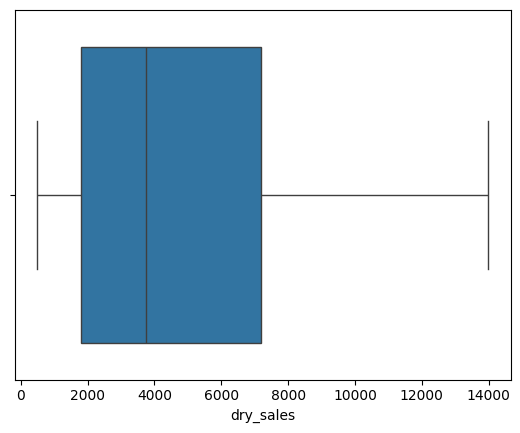

In [41]:
# box plot for the dry sales
sns.boxplot(x=test['dry_sales'])

<Axes: xlabel='fresh_sales'>

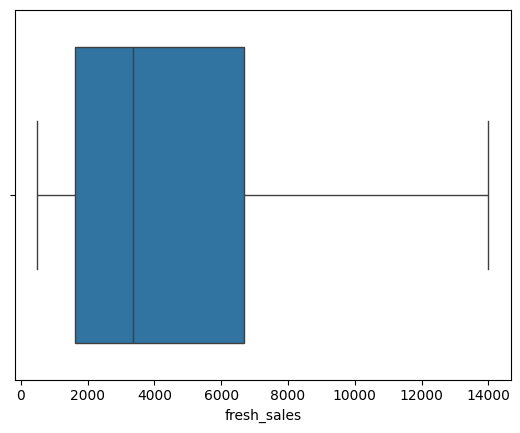

In [42]:
# box plot for the fresh sales
sns.boxplot(x=test['fresh_sales'])

<Axes: xlabel='luxury_sales'>

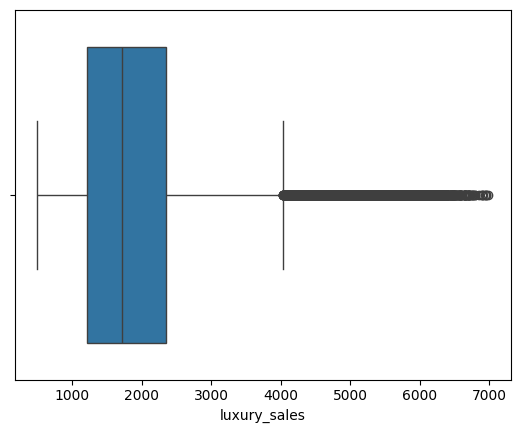

In [43]:
# box plot for the luxury sales
sns.boxplot(x=test['luxury_sales'])

Since the outlet city is a categorical variable - label encoding is used to present this data in a numeric format so that machine learning algorithms can process this data more effectively.

In [44]:
# import label encoder from sklearn
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [45]:
# fit encoder to outlet_city
encoder.fit(test['outlet_city'])

LabelEncoder()

In [46]:
# create encoded outlet city column
test['outlet_city_encoded'] = encoder.transform(test['outlet_city'])

In [47]:
test

,Customer_ID,outlet_city,luxury_sales,fresh_sales,dry_sales,outlet_city_encoded
0,33574,Batticaloa,2686.50,3582.00,12537.00,1
1,10089,Batticaloa,1717.56,2576.34,9446.58,1
2,38329,Batticaloa,854.04,1242.24,5201.88,1
3,11376,Batticaloa,1638.12,2320.67,9282.68,1
4,12410,Batticaloa,1039.09,1518.67,5435.24,1
...,...,...,...,...,...,...
40744,33698,Wattala,3916.48,4161.26,3916.48,21
40745,4185,Wattala,3191.92,3004.16,3098.04,21
40746,28664,Wattala,3838.60,3951.50,3700.00,21
40747,11874,Wattala,4313.76,4183.04,4313.76,21


In [48]:
test.dtypes

,0
Customer_ID,object
outlet_city,object
luxury_sales,float64
fresh_sales,float64
dry_sales,float64
outlet_city_encoded,int64


In [49]:
# Change outlet_city encoded to object data type
test['outlet_city_encoded'] = test['outlet_city_encoded'].astype(object)

In [50]:
test.dtypes

,0
Customer_ID,object
outlet_city,object
luxury_sales,float64
fresh_sales,float64
dry_sales,float64
outlet_city_encoded,object


## **EDA After Cleaning**

### Univariate

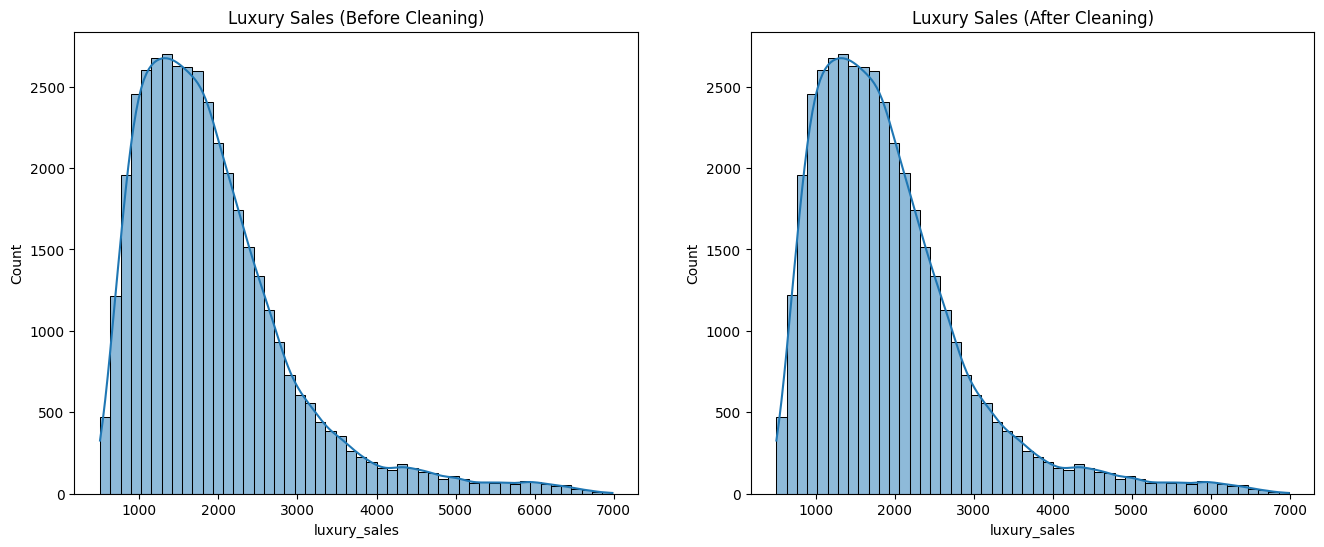

In [51]:
# Luxury Sales distribution
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
sns.histplot(test_before['luxury_sales'], bins=50, kde=True)
plt.title("Luxury Sales (Before Cleaning)")
plt.subplot(1, 2, 2)
sns.histplot(test['luxury_sales'], bins=50, kde=True)
plt.title("Luxury Sales (After Cleaning)")
plt.show()

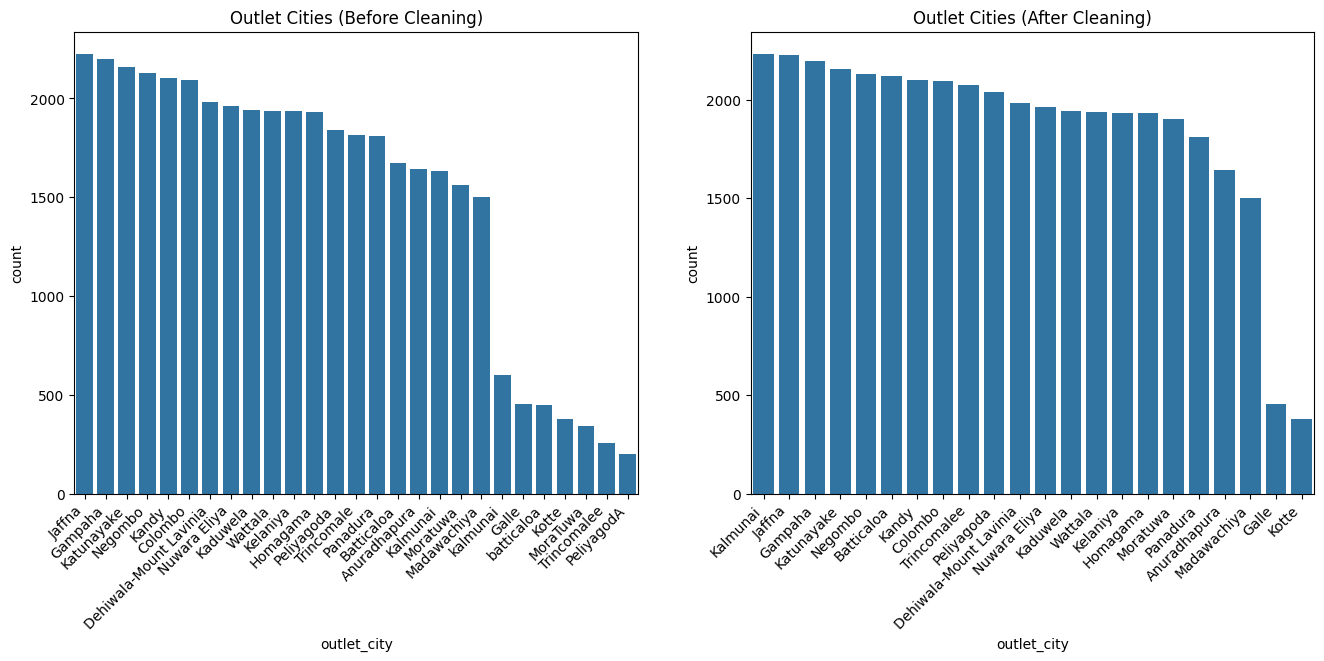

In [52]:
# Outlet cities distribution
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
sns.countplot(x='outlet_city', data=test_before, order=test_before['outlet_city'].value_counts().index)
plt.title('Outlet Cities (Before Cleaning)')
plt.xticks(rotation=45, ha='right')
plt.subplot(1, 2, 2)
sns.countplot(x='outlet_city', data=test, order=test['outlet_city'].value_counts().index)
plt.title('Outlet Cities (After Cleaning)')
plt.xticks(rotation=45, ha='right')
plt.show()

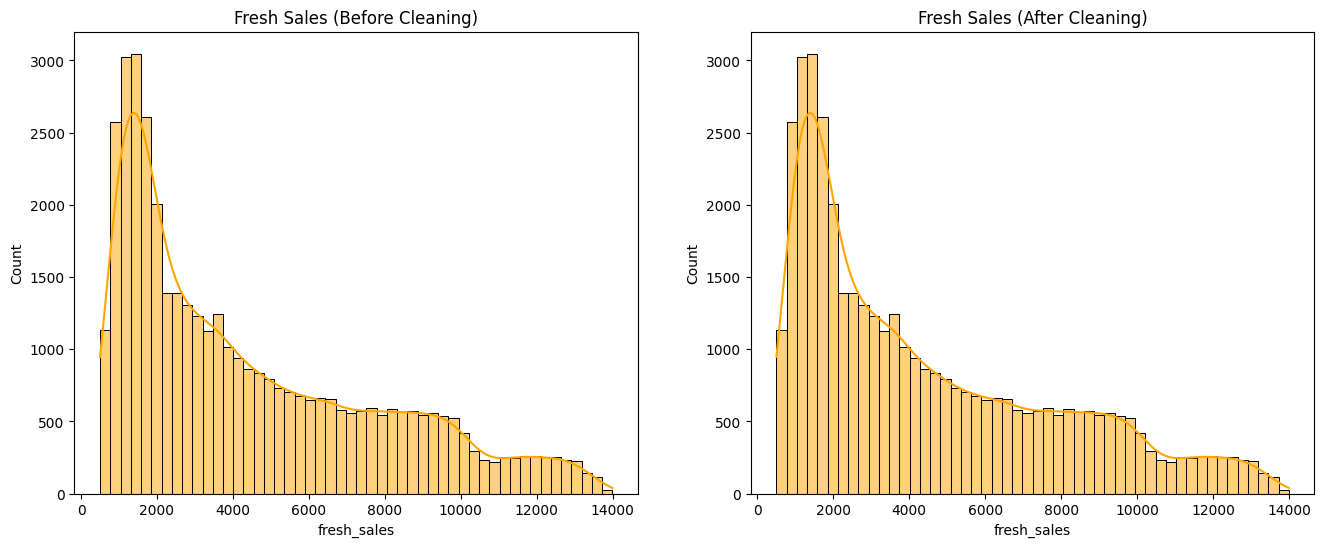

In [53]:
# Fresh Sales distribution
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
sns.histplot(test_before['fresh_sales'], bins=50, kde=True, color='orange')
plt.title("Fresh Sales (Before Cleaning)")
plt.subplot(1, 2, 2)
sns.histplot(test['fresh_sales'], bins=50, kde=True, color='orange')
plt.title("Fresh Sales (After Cleaning)")
plt.show()

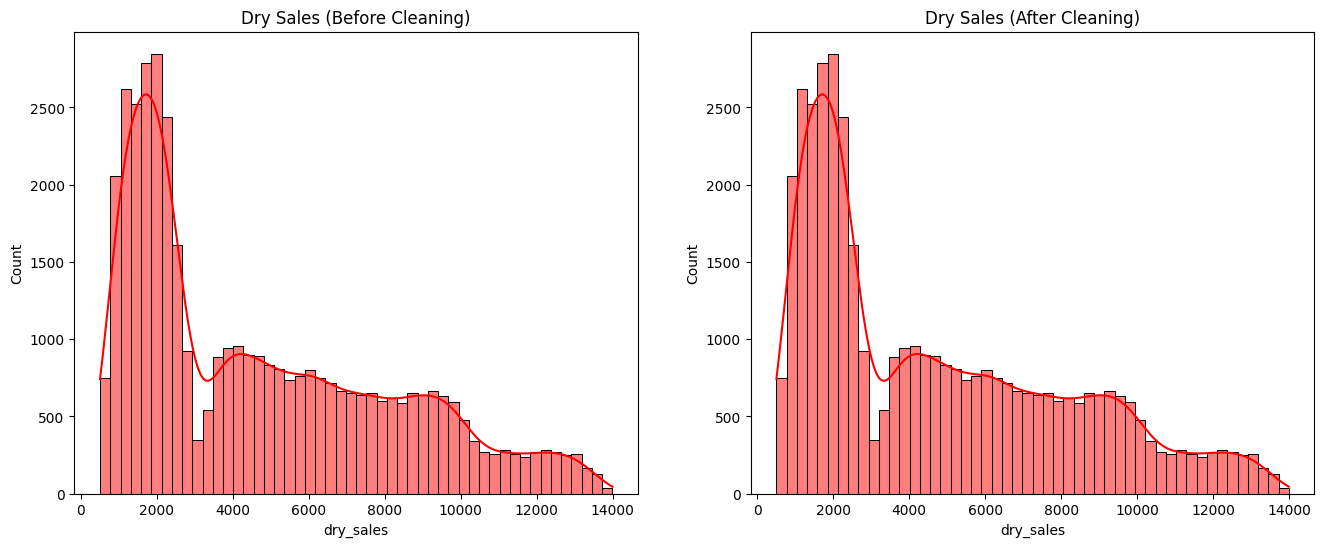

In [54]:
# dry sales distribution
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
sns.histplot(test_before['dry_sales'], bins=50, kde=True, color='red')
plt.title("Dry Sales (Before Cleaning)")
plt.subplot(1, 2, 2)
sns.histplot(test['dry_sales'], bins=50, kde=True, color='red')
plt.title("Dry Sales (After Cleaning)")
plt.show()

### Multivariate

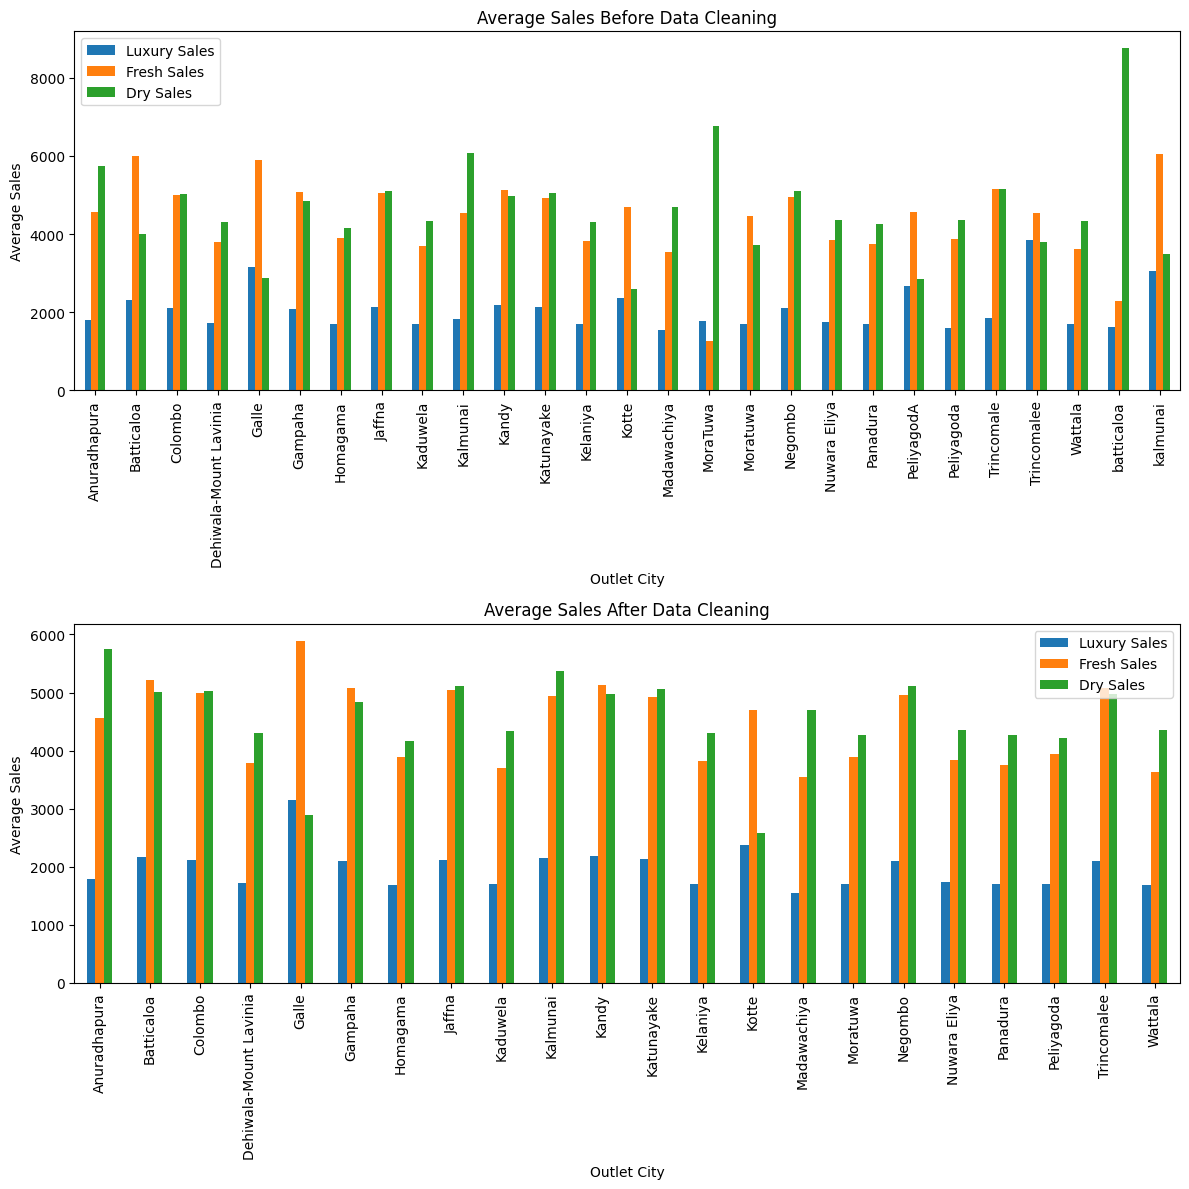

In [55]:
# Avg sales by sales type and city
test_before_grouped = test_before.groupby("outlet_city")[["luxury_sales", "fresh_sales", "dry_sales"]].mean(numeric_only=True).reset_index()
test_grouped = test.groupby("outlet_city")[["luxury_sales", "fresh_sales", "dry_sales"]].mean(numeric_only=True).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(12, 12))

test_before_grouped.plot(x="outlet_city", kind="bar", ax=axes[0])
axes[0].set_title("Average Sales Before Data Cleaning")
axes[0].set_xlabel("Outlet City")
axes[0].set_ylabel("Average Sales")
axes[0].tick_params(axis='x', rotation=90)
axes[0].legend(["Luxury Sales", "Fresh Sales", "Dry Sales"])

test_grouped.plot(x="outlet_city", kind="bar", ax=axes[1])
axes[1].set_title("Average Sales After Data Cleaning")
axes[1].set_xlabel("Outlet City")
axes[1].set_ylabel("Average Sales")
axes[1].tick_params(axis='x', rotation=90)
axes[1].legend(["Luxury Sales", "Fresh Sales", "Dry Sales"])

plt.tight_layout()
plt.show()

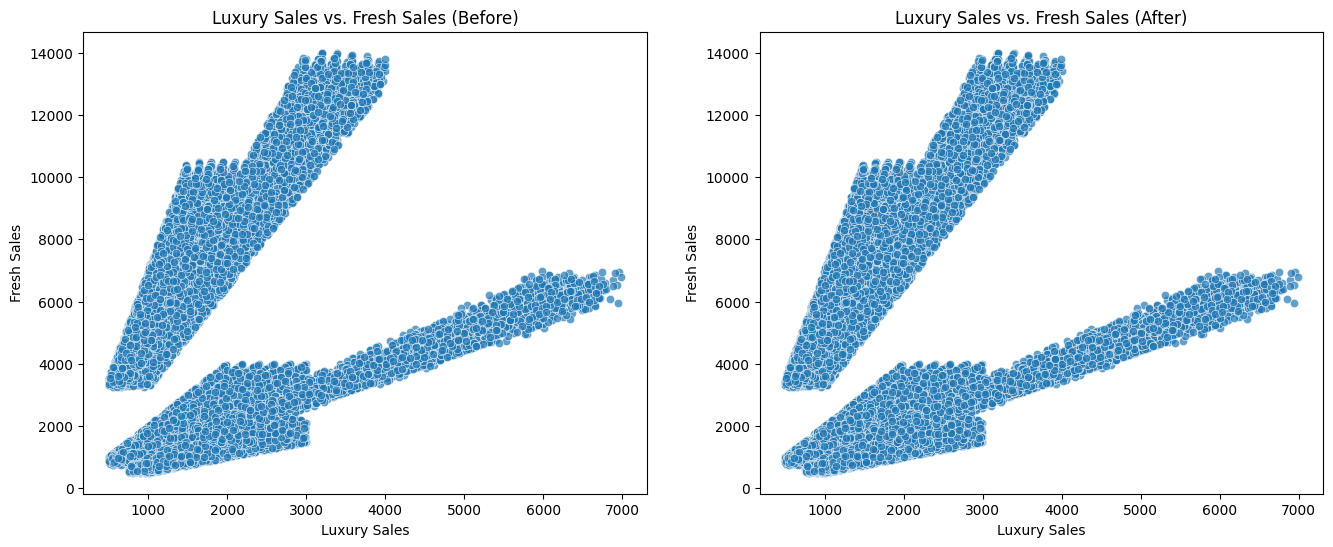

In [56]:
# Luxury sales Vs Fresh Sales
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=test_before, x="luxury_sales", y="fresh_sales", alpha=0.7, ax=axes[0])
axes[0].set_title("Luxury Sales vs. Fresh Sales (Before)")
axes[0].set_xlabel("Luxury Sales")
axes[0].set_ylabel("Fresh Sales")

sns.scatterplot(data=test, x="luxury_sales", y="fresh_sales", alpha=0.7, ax=axes[1])
axes[1].set_title("Luxury Sales vs. Fresh Sales (After)")
axes[1].set_xlabel("Luxury Sales")
axes[1].set_ylabel("Fresh Sales")

plt.show()

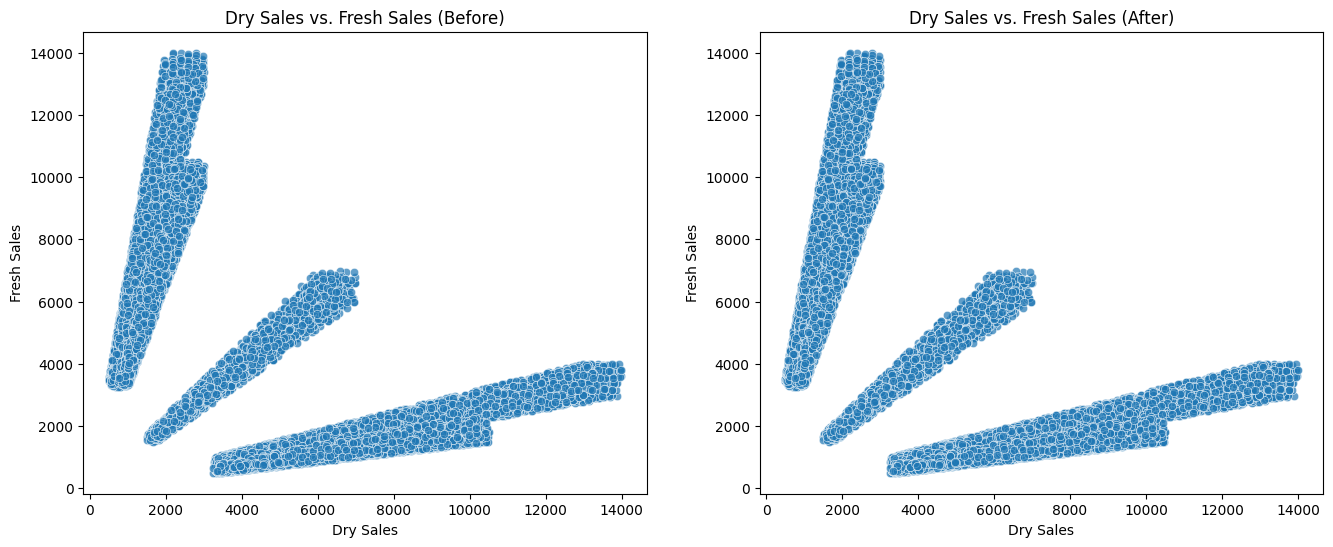

In [57]:
# Dry Sales Vs fresh Sales
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=test_before, x="dry_sales", y="fresh_sales", alpha=0.7, ax=axes[0])
axes[0].set_title("Dry Sales vs. Fresh Sales (Before)")
axes[0].set_xlabel("Dry Sales")
axes[0].set_ylabel("Fresh Sales")

sns.scatterplot(data=test, x="dry_sales", y="fresh_sales", alpha=0.7, ax=axes[1])
axes[1].set_title("Dry Sales vs. Fresh Sales (After)")
axes[1].set_xlabel("Dry Sales")
axes[1].set_ylabel("Fresh Sales")

plt.show()

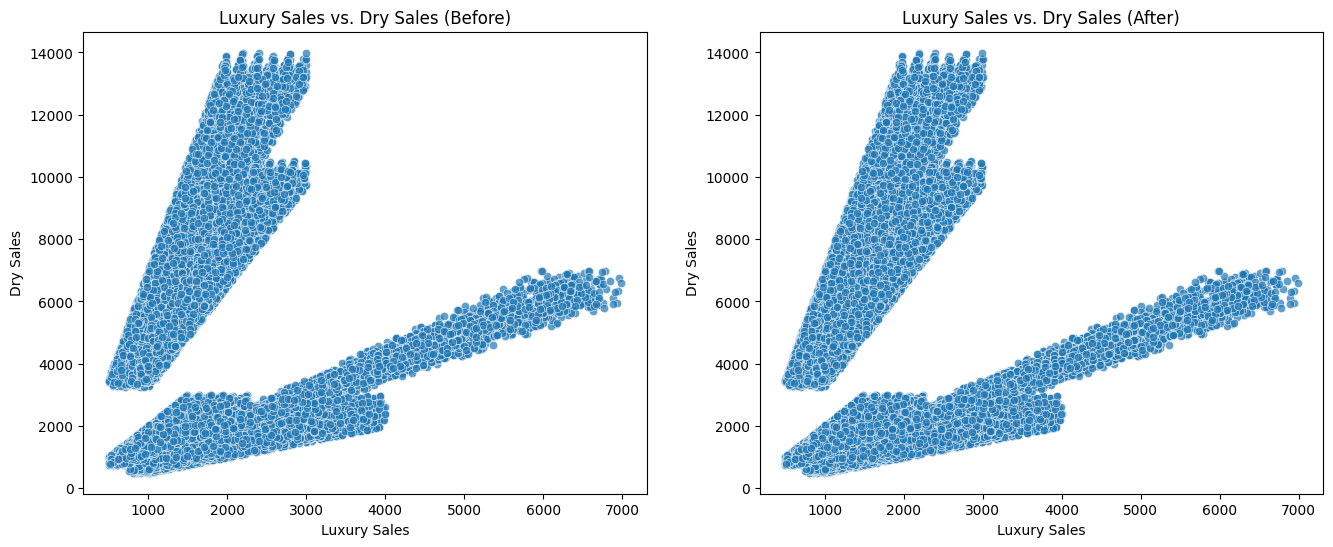

In [58]:
# Luxury Sales Vs Dry sales
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=test_before, x="luxury_sales", y="dry_sales", alpha=0.7, ax=axes[0])
axes[0].set_title("Luxury Sales vs. Dry Sales (Before)")
axes[0].set_xlabel("Luxury Sales")
axes[0].set_ylabel("Dry Sales")

sns.scatterplot(data=test, x="luxury_sales", y="dry_sales", alpha=0.7, ax=axes[1])
axes[1].set_title("Luxury Sales vs. Dry Sales (After)")
axes[1].set_xlabel("Luxury Sales")
axes[1].set_ylabel("Dry Sales")

plt.show()

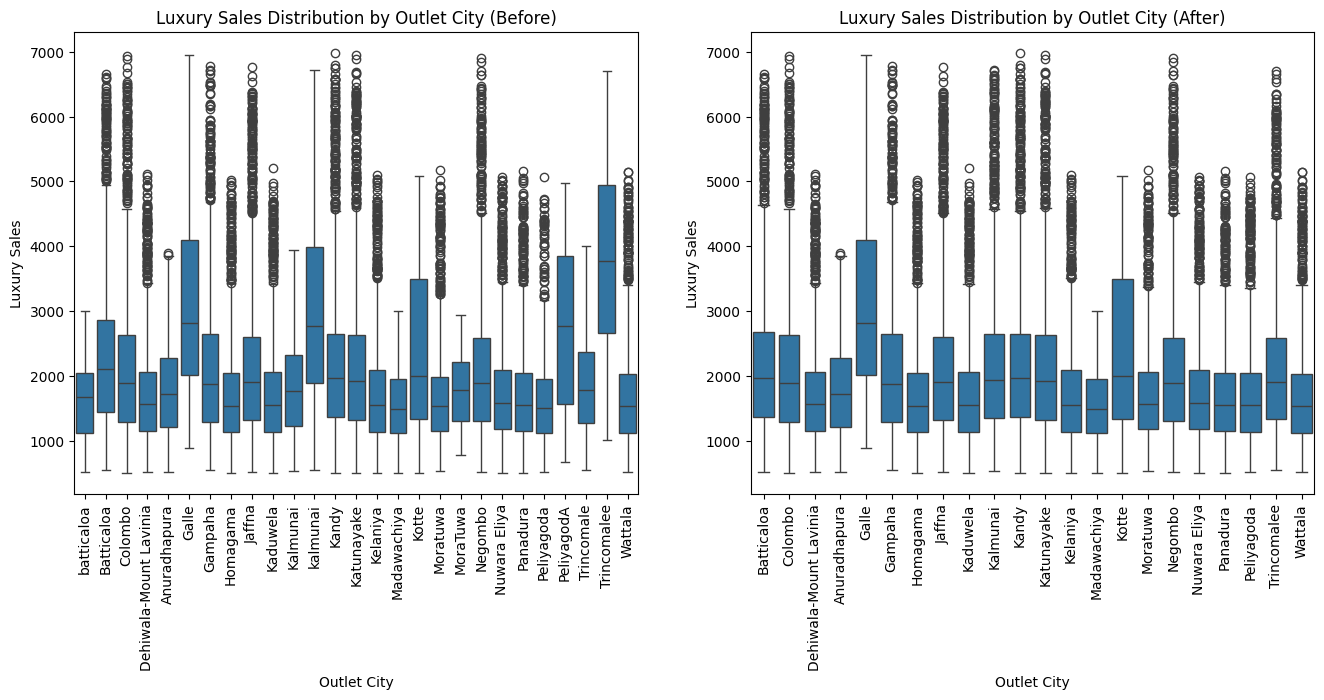

In [59]:
# Luxury sales distribution by outlet city
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(x="outlet_city", y="luxury_sales", data=test_before, ax=axes[0])
axes[0].set_title("Luxury Sales Distribution by Outlet City (Before)")
axes[0].set_xlabel("Outlet City")
axes[0].set_ylabel("Luxury Sales")
axes[0].tick_params(axis='x', rotation=90)

sns.boxplot(x="outlet_city", y="luxury_sales", data=test, ax=axes[1])
axes[1].set_title("Luxury Sales Distribution by Outlet City (After)")
axes[1].set_xlabel("Outlet City")
axes[1].set_ylabel("Luxury Sales")
axes[1].tick_params(axis='x', rotation=90)

plt.show()

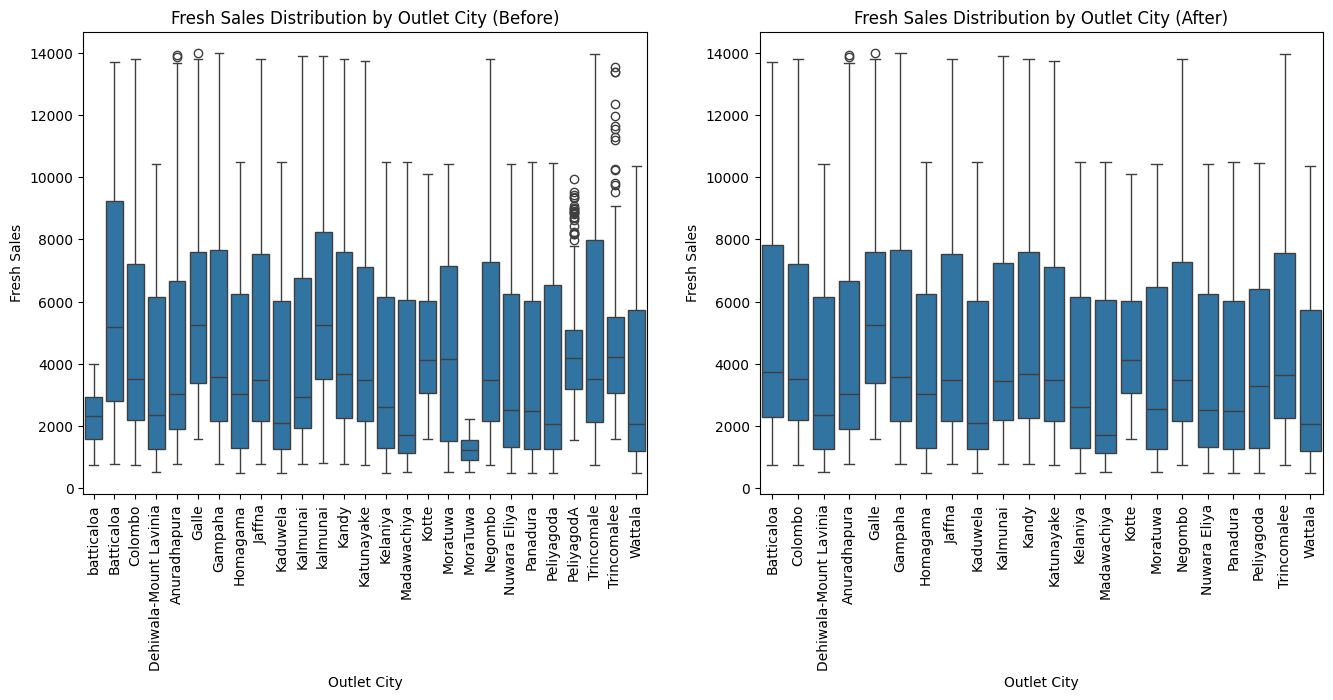

In [60]:
# Fresh sales distribution by outlet city
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(x="outlet_city", y="fresh_sales", data=test_before, ax=axes[0])
axes[0].set_title("Fresh Sales Distribution by Outlet City (Before)")
axes[0].set_xlabel("Outlet City")
axes[0].set_ylabel("Fresh Sales")
axes[0].tick_params(axis='x', rotation=90)

sns.boxplot(x="outlet_city", y="fresh_sales", data=test, ax=axes[1])
axes[1].set_title("Fresh Sales Distribution by Outlet City (After)")
axes[1].set_xlabel("Outlet City")
axes[1].set_ylabel("Fresh Sales")
axes[1].tick_params(axis='x', rotation=90)

plt.show()

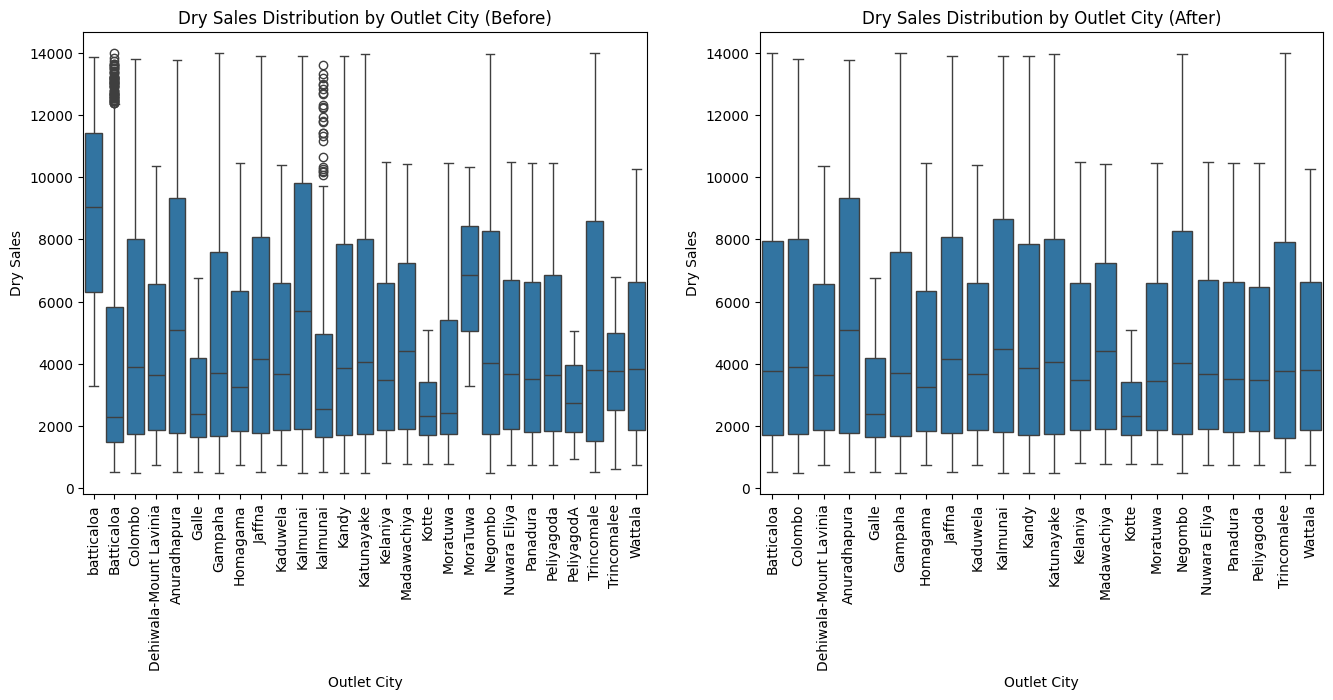

In [61]:
# Dry sales distribution by outlet city
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(x="outlet_city", y="dry_sales", data=test_before, ax=axes[0])
axes[0].set_title("Dry Sales Distribution by Outlet City (Before)")
axes[0].set_xlabel("Outlet City")
axes[0].set_ylabel("Dry Sales")
axes[0].tick_params(axis='x', rotation=90)

sns.boxplot(x="outlet_city", y="dry_sales", data=test, ax=axes[1])
axes[1].set_title("Dry Sales Distribution by Outlet City (After)")
axes[1].set_xlabel("Outlet City")
axes[1].set_ylabel("Dry Sales")
axes[1].tick_params(axis='x', rotation=90)

plt.show()

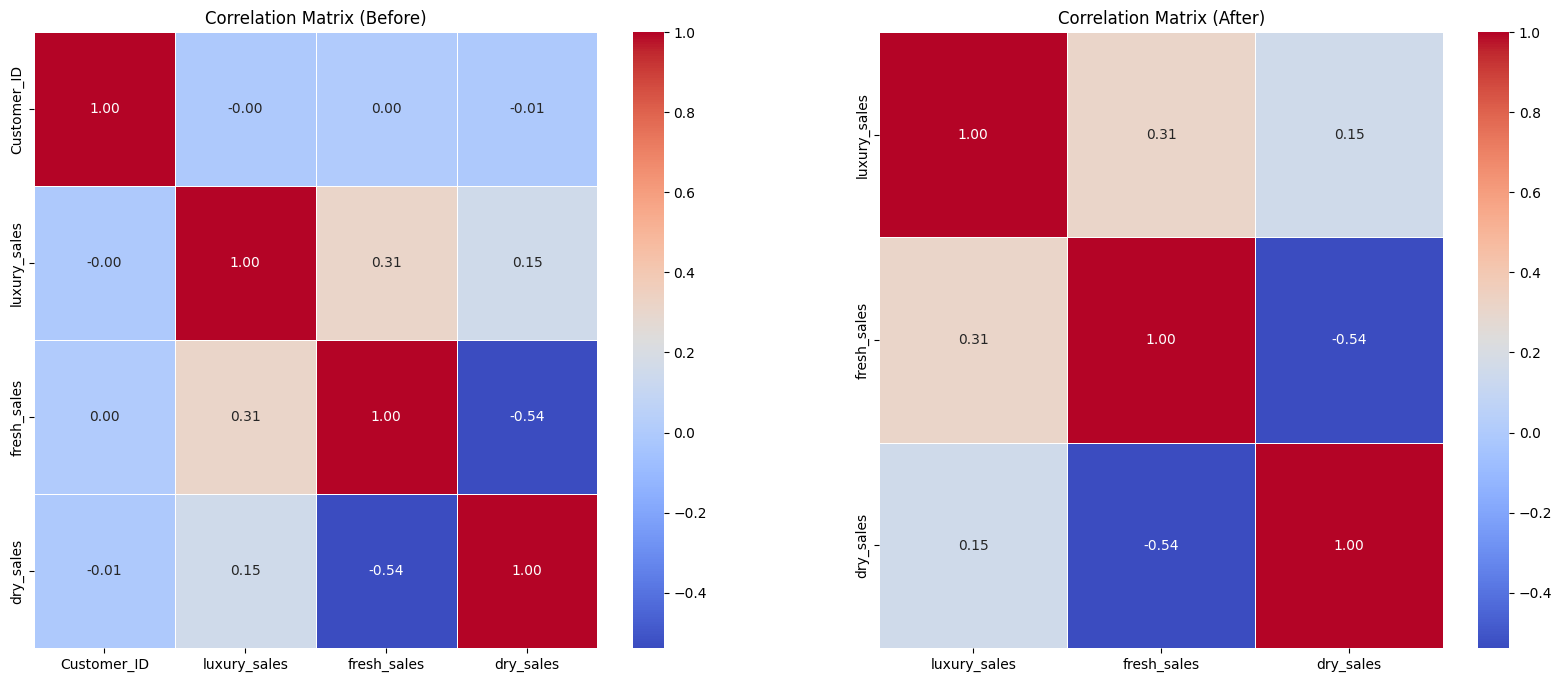

In [62]:
# Correlation Matrix
correlation_matrix_before = test_before.select_dtypes(include=np.number).corr()
correlation_matrix_after = test.select_dtypes(include=np.number).corr()

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(correlation_matrix_before, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, ax=axes[0])
axes[0].set_title('Correlation Matrix (Before)')

sns.heatmap(correlation_matrix_after, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, ax=axes[1])
axes[1].set_title('Correlation Matrix (After)')

plt.show()

#**Exporting clean data**

In [63]:
from google.colab import auth
from googleapiclient.discovery import build
from googleapiclient.http import MediaFileUpload

# Authenticate Google Drive access
auth.authenticate_user()
drive_service = build('drive', 'v3')

# Define Google Drive folder ID (Replace with your actual folder ID)
folder_id = "1XkRUF4MCrgqzis3v2C7Bx9GQaK5XgFZI"

# Define the CSV file name
file_name = "clean_test.csv"

# Search for the file inside the folder
query = f"'{folder_id}' in parents and name='{file_name}'"
results = drive_service.files().list(q=query, fields="files(id)").execute()
files = results.get("files", [])

# If file exists, delete it before uploading the new one
if files:
    file_id = files[0]['id']
    drive_service.files().delete(fileId=file_id).execute()

# Save DataFrame as CSV locally
local_path = f"/content/{file_name}"
test.to_csv(local_path, index=False)

# Upload the new file
file_metadata = {"name": file_name, "parents": [folder_id]}
media = MediaFileUpload(local_path, mimetype="text/csv")

uploaded_file = drive_service.files().create(
    body=file_metadata, media_body=media, fields="id"
).execute()

print(f"File '{file_name}' uploaded successfully!")

File 'clean_test.csv' uploaded successfully!


In [64]:
test

,Customer_ID,outlet_city,luxury_sales,fresh_sales,dry_sales,outlet_city_encoded
0,33574,Batticaloa,2686.50,3582.00,12537.00,1
1,10089,Batticaloa,1717.56,2576.34,9446.58,1
2,38329,Batticaloa,854.04,1242.24,5201.88,1
3,11376,Batticaloa,1638.12,2320.67,9282.68,1
4,12410,Batticaloa,1039.09,1518.67,5435.24,1
...,...,...,...,...,...,...
40744,33698,Wattala,3916.48,4161.26,3916.48,21
40745,4185,Wattala,3191.92,3004.16,3098.04,21
40746,28664,Wattala,3838.60,3951.50,3700.00,21
40747,11874,Wattala,4313.76,4183.04,4313.76,21


# **Train CSV**

## **Data Exploration**

In [65]:
# Original URL from Google Drive
url = 'https://drive.google.com/file/d/1sIIqjCXcHCM3H6BojQIq2tl0vs7Yokh9/view?usp=drive_link'

# Extract the file ID
file_id = url.split('/')[-2]

# Construct the direct file access URL
file_url = 'https://drive.google.com/uc?id=' + file_id

train = pd.read_csv(file_url)
train

<ipython-input-65-054d8b7cf7d8>:10: DtypeWarning: Columns (3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv(file_url)


,Customer_ID,outlet_city,luxury_sales,fresh_sales,dry_sales,cluster_catgeory
0,10493832.0,Kelaniya,1209.6,756.0,5292.0,4
1,10178643.0,Moratuwa,1590.12,1060.08,6007.12,1
2,10513916.0,Wattala,2288.88,1481.04,9155.52,4
3,10334589.0,Wattala,2274.94,1739.66,9099.76,4
4,10458365.0,Kelaniya,2345.49,2069.55,9243.99,4
...,...,...,...,...,...,...
774150,10197979.0,Gampaha,3893.4,3893.4,3448.44,3
774151,10494575.0,Katunayake,6095.86,5557.99,6275.15,3
774152,10565682.0,Colombo,5121.42,4820.16,4669.53,3
774153,10351977.0,Kandy,6311.76,6311.76,5940.48,3


In [66]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 774155 entries, 0 to 774154
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Customer_ID       774153 non-null  float64
 1   outlet_city       774153 non-null  object 
 2   luxury_sales      774120 non-null  object 
 3   fresh_sales       774114 non-null  object 
 4   dry_sales         774125 non-null  object 
 5   cluster_catgeory  774154 non-null  object 
dtypes: float64(1), object(5)
memory usage: 35.4+ MB


In [67]:
train.describe()

,Customer_ID
count,7.741530e+05
mean,1.038708e+07
std,2.234795e+05
min,1.000000e+07
25%,1.019354e+07
50%,1.038708e+07
75%,1.058062e+07
max,1.077415e+07


In [68]:
train.shape

(774155, 6)

In [69]:
unique_values_train = train.apply(pd.Series.unique)
print(unique_values_train)

Customer_ID         [10493832.0, 10178643.0, 10513916.0, 10334589....
outlet_city         [Kelaniya, Moratuwa, Wattala, Homagama, Dehiwa...
luxury_sales        [1209.6, 1590.12, 2288.88, 2274.94, 2345.49, 1...
fresh_sales         [756.0, 1060.08, 1481.04, 1739.66, 2069.55, 91...
dry_sales           [5292.0, 6007.12, 9155.52, 9099.76, 9243.99, 5...
cluster_catgeory    [4, 1, 99, 2, 5, 3, 6, 6\, 4, 2, 1, 95, 3, 98,...
dtype: object


In [70]:
missing_values_train = train.isnull().sum()
print(missing_values_train)

Customer_ID          2
outlet_city          2
luxury_sales        35
fresh_sales         41
dry_sales           30
cluster_catgeory     1
dtype: int64


In [71]:
num_duplicates_train = train.duplicated().sum()
num_duplicates_train

0

In [72]:
train.shape

(774155, 6)

## **EDA Before Cleaning**

### **UNIVARIATE**

In [73]:
train_before = train.copy()

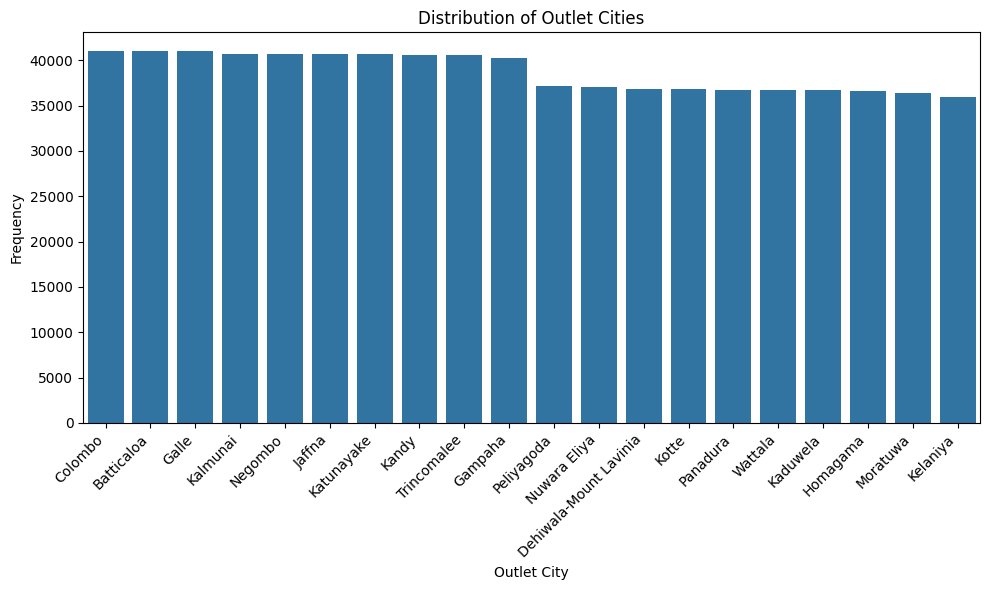

In [74]:
# Bar Plot - distribution of outlet cities
plt.figure(figsize=(10, 6))
sns.countplot(x='outlet_city', data=train_before, order=train_before['outlet_city'].value_counts().index)
plt.title('Distribution of Outlet Cities')
plt.xlabel('Outlet City')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

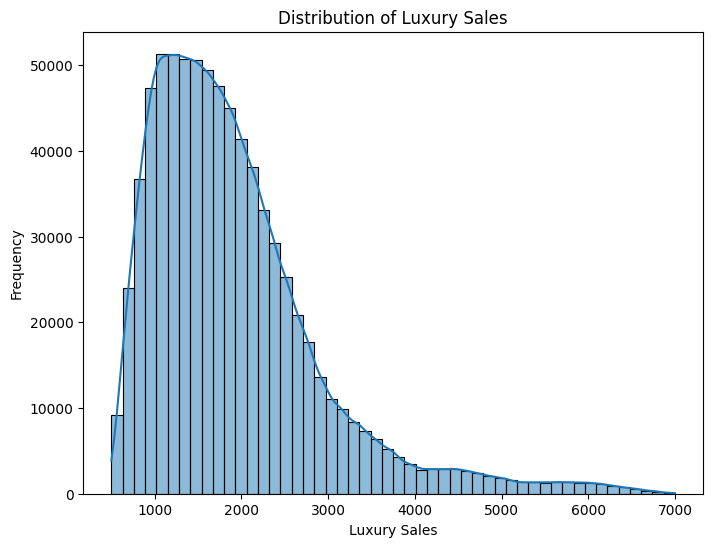

In [75]:
# distribution of luxury sales
train_before['luxury_sales'] = pd.to_numeric(train_before['luxury_sales'], errors='coerce').astype(float)

plt.figure(figsize=(8, 6))
sns.histplot(train_before["luxury_sales"], bins=50, kde=True)
plt.title("Distribution of Luxury Sales")
plt.xlabel("Luxury Sales")
plt.ylabel("Frequency")
plt.show()

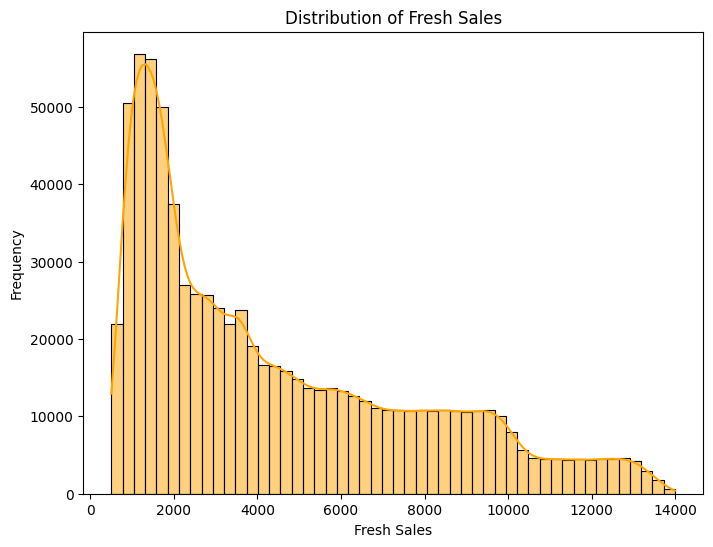

In [76]:
# distribution of fresh sales
train_before['fresh_sales'] = pd.to_numeric(train_before['fresh_sales'], errors='coerce').astype(float)

plt.figure(figsize=(8, 6))
sns.histplot(train_before['fresh_sales'], bins=50, kde=True, color='orange')
plt.title("Distribution of Fresh Sales")
plt.xlabel("Fresh Sales")
plt.ylabel("Frequency")
plt.show()

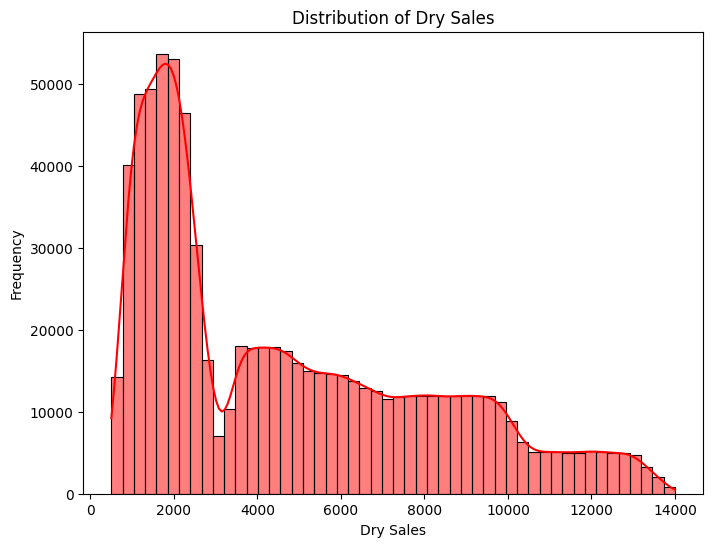

In [77]:
# distribution of dry sales
train_before['dry_sales'] = pd.to_numeric(train_before['dry_sales'], errors='coerce').astype(float)

plt.figure(figsize=(8, 6))
sns.histplot(train_before['dry_sales'], bins=50, kde=True, color='red')
plt.title("Distribution of Dry Sales")
plt.xlabel("Dry Sales")
plt.ylabel("Frequency")
plt.show()

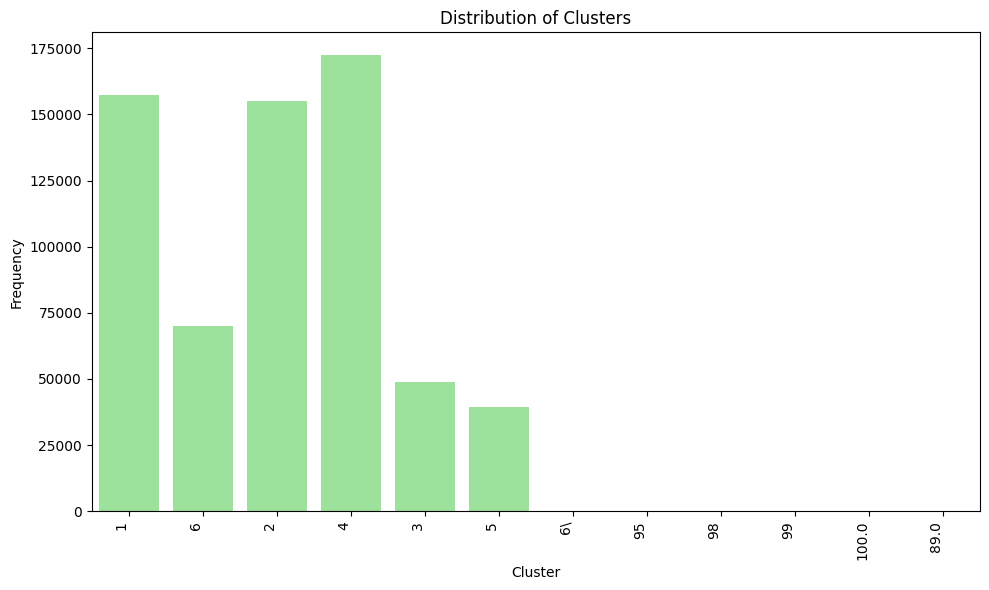

In [78]:
# Bar Plot for "cluster" column
plt.figure(figsize=(10, 6))
sns.countplot(x='cluster_catgeory', data=train_before, order=train_before['cluster_catgeory'].value_counts().index, color='lightgreen')
plt.title('Distribution of Clusters')
plt.xlabel('Cluster')
plt.ylabel('Frequency')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

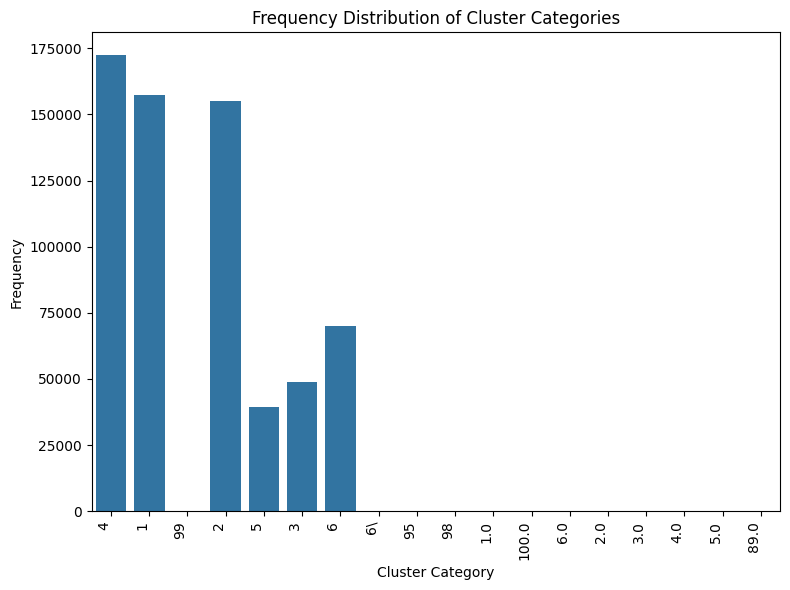

In [79]:
# frequency distribution of cluster categories
plt.figure(figsize=(8, 6))
sns.countplot(x='cluster_catgeory', data=train_before)
plt.title("Frequency Distribution of Cluster Categories")
plt.xlabel("Cluster Category")
plt.ylabel("Frequency")
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

### **Multivariate**


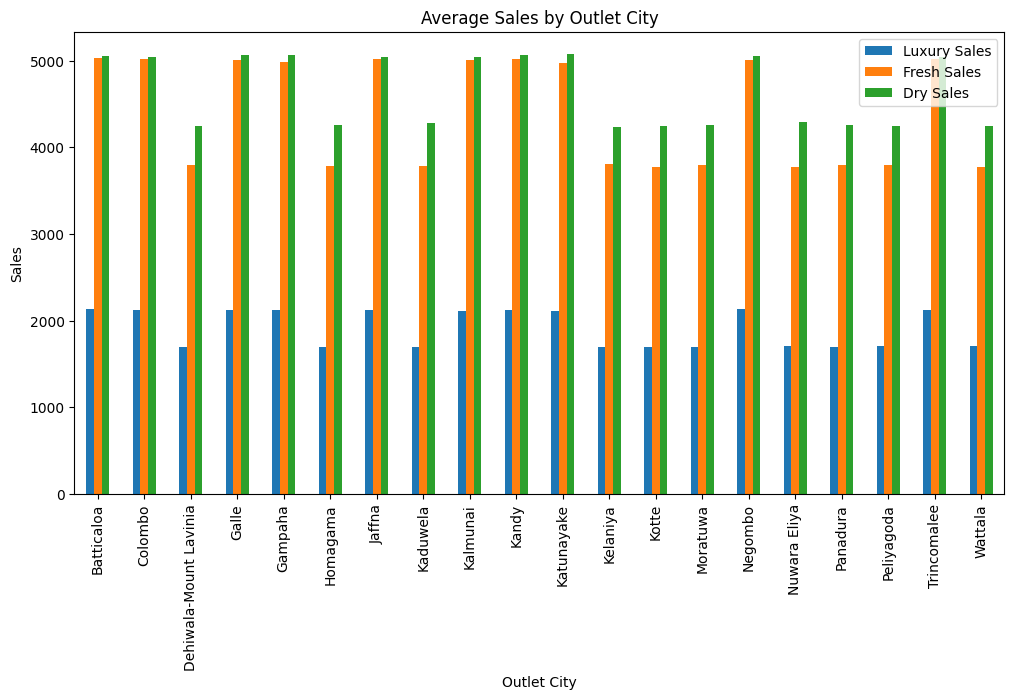

In [80]:
# Average sales by outlet city
train_grouped = train_before.groupby("outlet_city")[["luxury_sales", "fresh_sales", "dry_sales"]].mean(numeric_only=True).reset_index()
train_grouped.plot(x="outlet_city", kind="bar", figsize=(12,6))
plt.title("Average Sales by Outlet City")
plt.xlabel("Outlet City")
plt.ylabel("Sales")
plt.xticks(rotation=90)
plt.legend(["Luxury Sales", "Fresh Sales", "Dry Sales"])
plt.show()

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


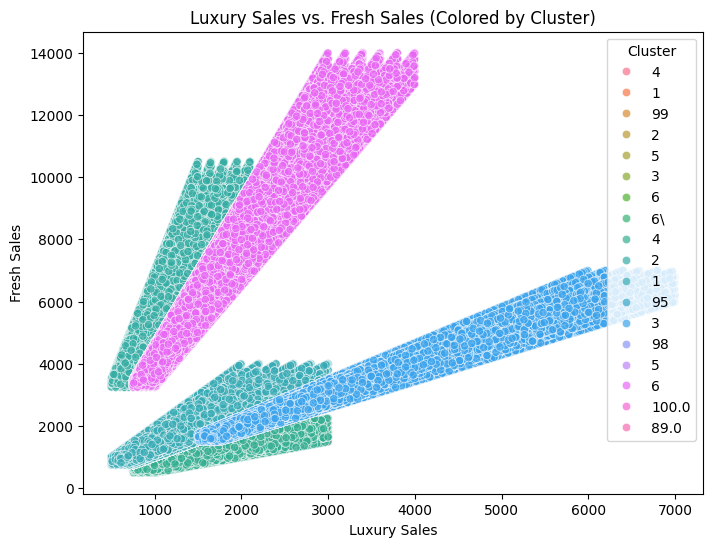

In [81]:
# Create the scatter plot for Luxury sales Vs Fresh Sales
plt.figure(figsize=(8, 6))
sns.scatterplot(data=train_before, x="luxury_sales", y="fresh_sales", hue="cluster_catgeory", alpha=0.7)
plt.title("Luxury Sales vs. Fresh Sales (Colored by Cluster)")
plt.xlabel("Luxury Sales")
plt.ylabel("Fresh Sales")
plt.legend(title="Cluster")
plt.show()

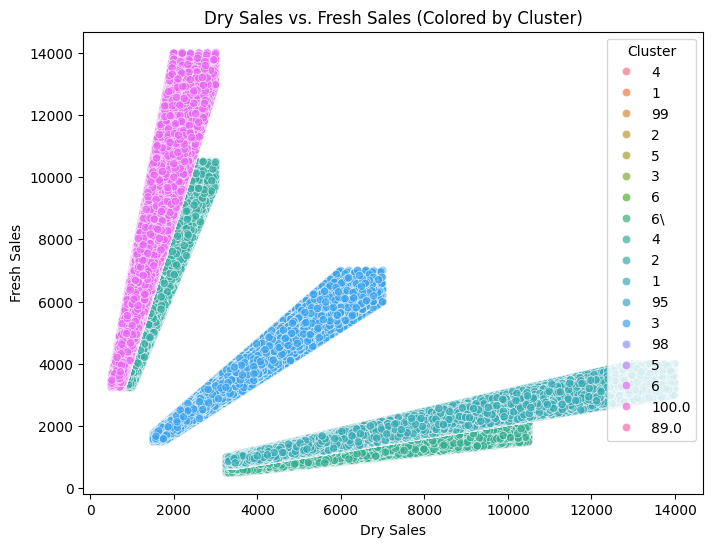

In [82]:
# Create the scatter plot for dry sales Vs Fresh Sales
plt.figure(figsize=(8, 6))
sns.scatterplot(data=train_before, x="dry_sales", y="fresh_sales", hue="cluster_catgeory", alpha=0.7)
plt.title("Dry Sales vs. Fresh Sales (Colored by Cluster)")
plt.xlabel("Dry Sales")
plt.ylabel("Fresh Sales")
plt.legend(title="Cluster")
plt.show()

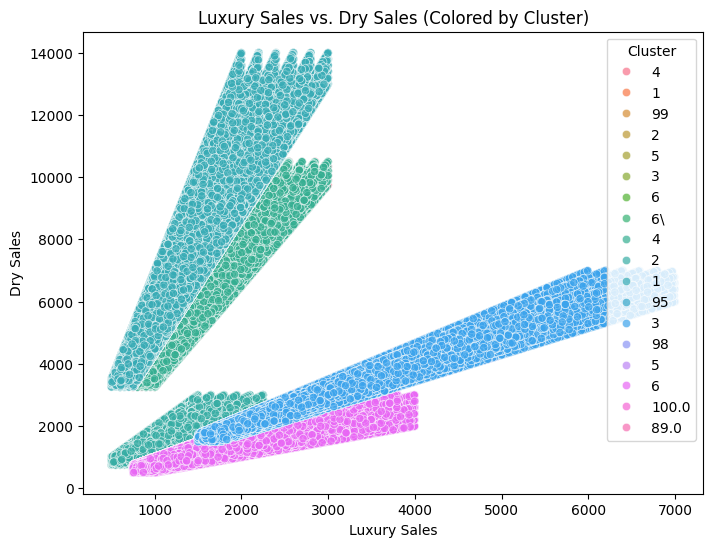

In [83]:
# Create the scatter plot for luxury sales Vs Dry Sales
plt.figure(figsize=(8, 6))
sns.scatterplot(data=train_before, x="luxury_sales", y="dry_sales", hue="cluster_catgeory", alpha=0.7)
plt.legend(title="Cluster")
plt.title("Luxury Sales vs. Dry Sales (Colored by Cluster)")
plt.xlabel("Luxury Sales")
plt.ylabel("Dry Sales")
plt.legend(title="Cluster")
plt.show()

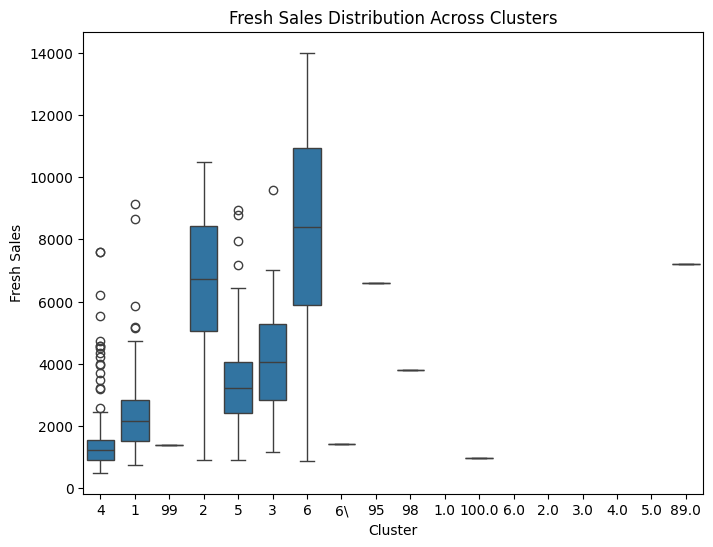

In [84]:
# Fresh sales distribution by cluster
plt.figure(figsize=(8, 6))
sns.boxplot(data=train_before, x="cluster_catgeory", y="fresh_sales")
plt.title("Fresh Sales Distribution Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Fresh Sales")
plt.show()

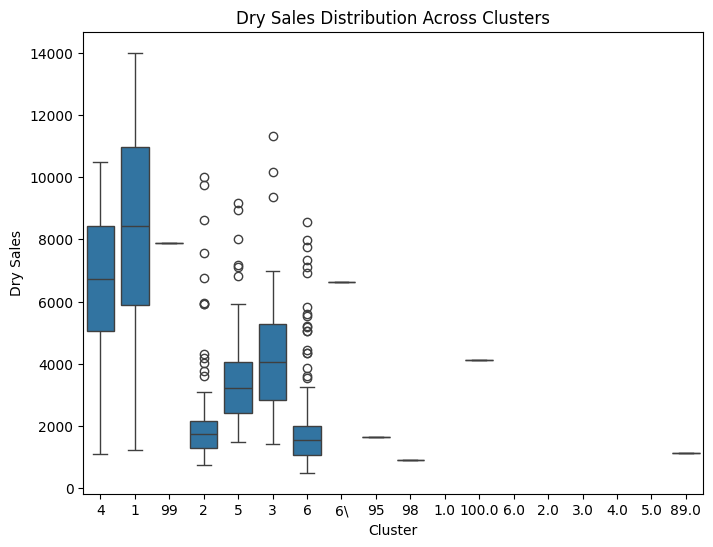

In [85]:
# Dry sales distribution by cluster
plt.figure(figsize=(8, 6))
sns.boxplot(data=train_before, x="cluster_catgeory", y="dry_sales")
plt.title("Dry Sales Distribution Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Dry Sales")
plt.show()

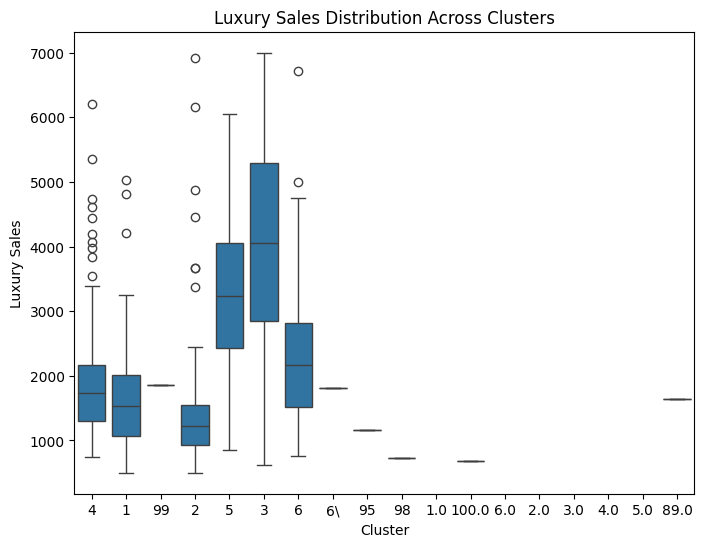

In [86]:
# Luxury sales distribution by cluster
plt.figure(figsize=(8, 6))
sns.boxplot(data=train_before, x="cluster_catgeory", y="luxury_sales")
plt.title("Luxury Sales Distribution Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Luxury Sales")
plt.show()

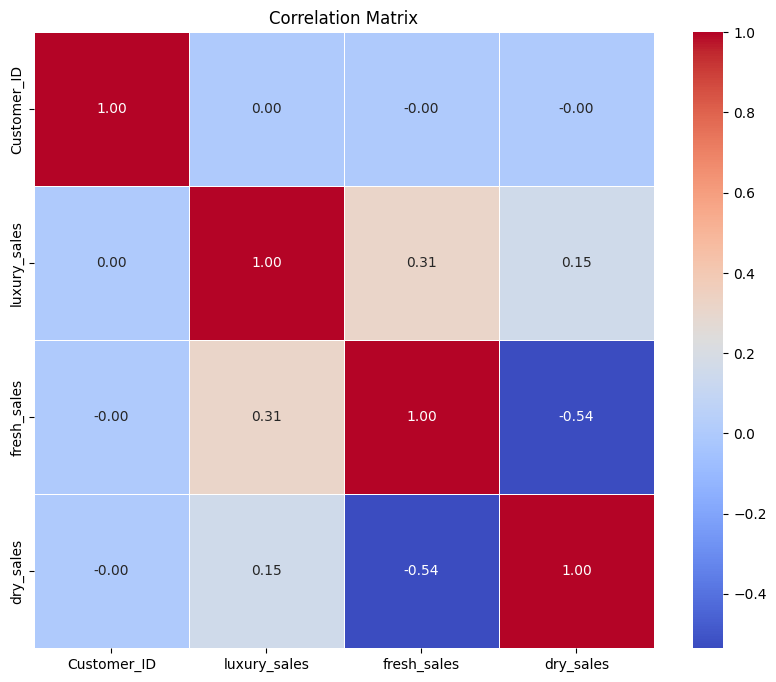

In [87]:
# Correlation Matrix
correlation_matrix = train_before.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix')
plt.show()

## **Data Cleaning**

In [88]:
# Original URL from Google Drive
url = 'https://drive.google.com/file/d/1sIIqjCXcHCM3H6BojQIq2tl0vs7Yokh9/view?usp=drive_link'

# Extract the file ID
file_id = url.split('/')[-2]

# Construct the direct file access URL
file_url = 'https://drive.google.com/uc?id=' + file_id

# Load the dataset
train = pd.read_csv(file_url, dtype={'fresh_sales': str, 'luxury_sales': str, 'dry_sales': str, 'cluster_catgeory': str})
train

,Customer_ID,outlet_city,luxury_sales,fresh_sales,dry_sales,cluster_catgeory
0,10493832.0,Kelaniya,1209.6,756,5292,4
1,10178643.0,Moratuwa,1590.12,1060.08,6007.12,1
2,10513916.0,Wattala,2288.88,1481.04,9155.52,4
3,10334589.0,Wattala,2274.94,1739.66,9099.76,4
4,10458365.0,Kelaniya,2345.49,2069.55,9243.99,4
...,...,...,...,...,...,...
774150,10197979.0,Gampaha,3893.4,3893.4,3448.44,3
774151,10494575.0,Katunayake,6095.86,5557.99,6275.15,3
774152,10565682.0,Colombo,5121.42,4820.16,4669.53,3
774153,10351977.0,Kandy,6311.76,6311.76,5940.48,3


In [89]:
# shape of the dataframe
train.shape

(774155, 6)

In [90]:
# Check data types
train.dtypes

,0
Customer_ID,float64
outlet_city,object
luxury_sales,object
fresh_sales,object
dry_sales,object
cluster_catgeory,object


In [91]:
# Check for number of missing values in each coulmn
train.isnull().sum()

,0
Customer_ID,2
outlet_city,2
luxury_sales,35
fresh_sales,41
dry_sales,30
cluster_catgeory,1


In [92]:
# change the object data types to float for sales features
train['fresh_sales'] = pd.to_numeric(train['fresh_sales'].str.replace(',', '',regex=True), errors='coerce')
train['luxury_sales'] = pd.to_numeric(train['luxury_sales'].str.replace(',', '',regex=True), errors='coerce')
train['dry_sales'] = pd.to_numeric(train['dry_sales'].str.replace(',', '',regex=True), errors='coerce')

In [93]:
# Check for number of missing values in each coulmn
train.isnull().sum()

,0
Customer_ID,2
outlet_city,2
luxury_sales,45
fresh_sales,50
dry_sales,38
cluster_catgeory,1


In [94]:
# Total number of rows with missing values
train.isnull().any(axis=1).sum()

116

In [95]:
# display the rows with null values
train[train.isnull().any(axis=1)]

,Customer_ID,outlet_city,luxury_sales,fresh_sales,dry_sales,cluster_catgeory
4234,10101878.0,Dehiwala-Mount Lavinia,NaN,1686.36,9556.04,4
4326,10531406.0,Kaduwela,925.80,NaN,4011.80,4
4327,10311229.0,Panadura,2374.00,NaN,7715.50,4
4333,10361798.0,Kotte,NaN,NaN,6589.44,4
4929,10414692.0,Kaduwela,1780.80,NaN,NaN,4
...,...,...,...,...,...,...
754304,10006333.0,Batticaloa,3932.66,NaN,4186.38,3
754306,10726566.0,Jaffna,2728.95,2417.07,NaN,3
755630,10537627.0,Gampaha,NaN,5371.37,5717.91,3
765777,10499622.0,Katunayake,5315.57,NaN,5829.98,3


In [96]:
# display the tuples with cluster category null
train[train['cluster_catgeory'].isnull()]

,Customer_ID,outlet_city,luxury_sales,fresh_sales,dry_sales,cluster_catgeory
555560,10158111.0,Kalmunai,1730.52,2451.57,9662.07,NaN


In [97]:
# display the tuples with luxury sales null
train[train['luxury_sales'].isnull()]

,Customer_ID,outlet_city,luxury_sales,fresh_sales,dry_sales,cluster_catgeory
4234,10101878.0,Dehiwala-Mount Lavinia,NaN,1686.36,9556.04,4
4333,10361798.0,Kotte,NaN,NaN,6589.44,4
5375,10556752.0,Moratuwa,NaN,1328.88,7751.80,4
5408,10321643.0,Peliyagoda,NaN,NaN,3630.09,4
78367,10424117.0,Kotte,NaN,NaN,3472.08,4
78380,10343473.0,Peliyagoda,NaN,NaN,7337.40,4
80043,10774052.0,Kelaniya,NaN,1118.00,5934.00,4
174628,10207785.0,Kelaniya,NaN,9322.50,2683.75,2
175278,10347733.0,Peliyagoda,NaN,4286.28,NaN,2
296621,10215937.0,Panadura,NaN,8155.11,NaN,2


In [98]:
# display the tuples with fresh sales null
train[train['fresh_sales'].isnull()]

,Customer_ID,outlet_city,luxury_sales,fresh_sales,dry_sales,cluster_catgeory
4326,10531406.0,Kaduwela,925.80,NaN,4011.80,4
4327,10311229.0,Panadura,2374.00,NaN,7715.50,4
4333,10361798.0,Kotte,NaN,NaN,6589.44,4
4929,10414692.0,Kaduwela,1780.80,NaN,NaN,4
5379,10600529.0,Wattala,1405.40,NaN,4637.82,4
5403,10484539.0,Peliyagoda,1167.20,NaN,4085.20,4
5408,10321643.0,Peliyagoda,NaN,NaN,3630.09,4
78367,10424117.0,Kotte,NaN,NaN,3472.08,4
78380,10343473.0,Peliyagoda,NaN,NaN,7337.40,4
78400,10504943.0,Moratuwa,2312.16,NaN,NaN,4


In [99]:
# display the tuples with dry sales null
train[train['dry_sales'].isnull()]

,Customer_ID,outlet_city,luxury_sales,fresh_sales,dry_sales,cluster_catgeory
4929,10414692.0,Kaduwela,1780.80,NaN,NaN,4
78400,10504943.0,Moratuwa,2312.16,NaN,NaN,4
148029,10190107.0,Dehiwala-Mount Lavinia,931.50,931.50,NaN,4
174631,10273730.0,Homagama,1074.36,5141.58,NaN,2
174720,10039004.0,Kaduwela,944.44,4722.20,NaN,2
175278,10347733.0,Peliyagoda,NaN,4286.28,NaN,2
268571,10047014.0,Panadura,1808.30,NaN,NaN,2
296621,10215937.0,Panadura,NaN,8155.11,NaN,2
327168,10649653.0,Kotte,626.16,3548.24,NaN,2
327169,10737280.0,Nuwara Eliya,820.20,5741.40,NaN,2


According to the EDA since these three types of sales show a skewwed distribution, median imputattion was used to replace the missing values. The median sales for the relevant outlet city

In [100]:
# Calculate the median luxury sales for each outlet city
median_luxury_sales_by_city = train.groupby('outlet_city')['luxury_sales'].median()

# Fill missing values using the median for the corresponding outlet city
train['luxury_sales'] = train.apply(
    lambda row: median_luxury_sales_by_city[row['outlet_city']] if pd.isnull(row['luxury_sales']) else row['luxury_sales'],
    axis=1)

# display the tuples with luxury sales null
train[train['luxury_sales'].isnull()]

,Customer_ID,outlet_city,luxury_sales,fresh_sales,dry_sales,cluster_catgeory


In [101]:
# Calculate the median fresh sales for each outlet city
median_fresh_sales_by_city = train.groupby('outlet_city')['fresh_sales'].median()

# Fill missing values using the median for the corresponding outlet city
train['fresh_sales'] = train.apply(
    lambda row: median_fresh_sales_by_city[row['outlet_city']] if pd.isnull(row['fresh_sales']) else row['fresh_sales'],
    axis=1)

# display the tuples with fresh sales null
train[train['fresh_sales'].isnull()]

,Customer_ID,outlet_city,luxury_sales,fresh_sales,dry_sales,cluster_catgeory


In [102]:
# Calculate the median dry sales for each outlet city
median_dry_sales_by_city = train.groupby('outlet_city')['dry_sales'].median()

# Fill missing values using the median for the corresponding outlet city
train['dry_sales'] = train.apply(
    lambda row: median_dry_sales_by_city[row['outlet_city']] if pd.isnull(row['dry_sales']) else row['dry_sales'],
    axis=1)

# display the tuples with dry sales null
train[train['dry_sales'].isnull()]

,Customer_ID,outlet_city,luxury_sales,fresh_sales,dry_sales,cluster_catgeory


In [103]:
# Calculating the percentage of the missing values
print(train.isnull().sum()/len(train)*100)
print(train.isnull().any(axis=1).sum()/len(train)*100)

Customer_ID         0.000258
outlet_city         0.000258
luxury_sales        0.000000
fresh_sales         0.000000
dry_sales           0.000000
cluster_catgeory    0.000129
dtype: float64
0.0006458654920526251


In [104]:
# since very low percentage & MACR - drop the null rows
train.dropna(inplace=True)
train.isnull().sum()

,0
Customer_ID,0
outlet_city,0
luxury_sales,0
fresh_sales,0
dry_sales,0
cluster_catgeory,0


In [105]:
# change the customer ID feature to string datatype
train['Customer_ID'] = train['Customer_ID'].astype(str)
# Check data types
train.dtypes

,0
Customer_ID,object
outlet_city,object
luxury_sales,float64
fresh_sales,float64
dry_sales,float64
cluster_catgeory,object


In [106]:
# check for duplicates in customer ID
train[train['Customer_ID'].duplicated()]

,Customer_ID,outlet_city,luxury_sales,fresh_sales,dry_sales,cluster_catgeory


In [107]:
# Check the unique values in outlet city feature
train['outlet_city'].unique()

array(['Kelaniya', 'Moratuwa', 'Wattala', 'Homagama',
       'Dehiwala-Mount Lavinia', 'Panadura', 'Kaduwela', 'Peliyagoda',
       'Kotte', 'Nuwara Eliya', 'Batticaloa', 'Colombo', 'Jaffna',
       'Gampaha', 'Kalmunai', 'Galle', 'Katunayake', 'Negombo',
       'Trincomalee', 'Kandy'], dtype=object)

In [108]:
train['outlet_city'].nunique()

20

In [109]:
# Check the unique values from the cluster category feature
train['cluster_catgeory'].unique()

array(['4', '1', '99', '2', '5', '3', '6', '6\\', '95', '98', '100', '89'],
      dtype=object)

In [110]:
# Correct the wrong values
train['cluster_catgeory'] = train['cluster_catgeory'].str.replace('6\\', '6')

In [111]:
# Check the unique values from the cluster category feature
train['cluster_catgeory'].unique()

array(['4', '1', '99', '2', '5', '3', '6', '95', '98', '100', '89'],
      dtype=object)

In [112]:
# Rows with cluster category 100
train[train['cluster_catgeory'] == "100"]

,Customer_ID,outlet_city,luxury_sales,fresh_sales,dry_sales,cluster_catgeory
555703,10282701.0,Katunayake,678.26,986.56,4131.22,100


In [113]:
# drop the rows with invalid cluster categories
train = train.drop(train[(train['cluster_catgeory'] == "99") |
                         (train['cluster_catgeory'] == "100" ) |
                          (train['cluster_catgeory'] == "95") |
                           (train['cluster_catgeory'] == "98") |
                            (train['cluster_catgeory'] == "89")].index)

In [114]:
# Rows with cluster category 100
train[train['cluster_catgeory'] == "100"]

,Customer_ID,outlet_city,luxury_sales,fresh_sales,dry_sales,cluster_catgeory


<Axes: xlabel='luxury_sales'>

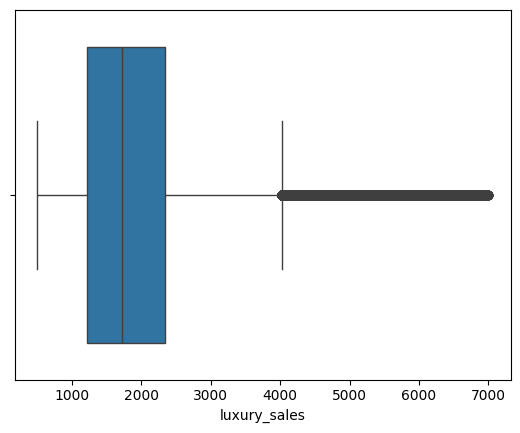

In [115]:
# box plot for the luxury sales
sns.boxplot(x=train['luxury_sales'])

<Axes: xlabel='fresh_sales'>

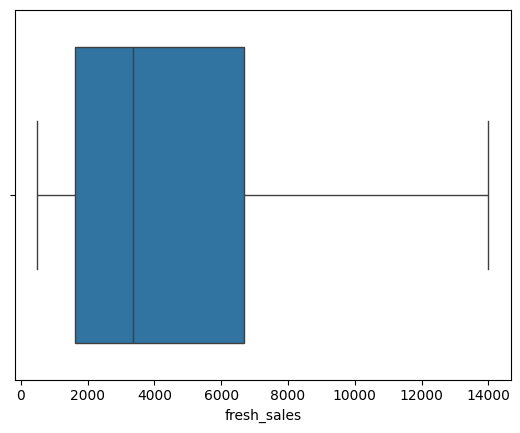

In [116]:
# box plot for the fresh sales
sns.boxplot(x=train['fresh_sales'])

<Axes: xlabel='dry_sales'>

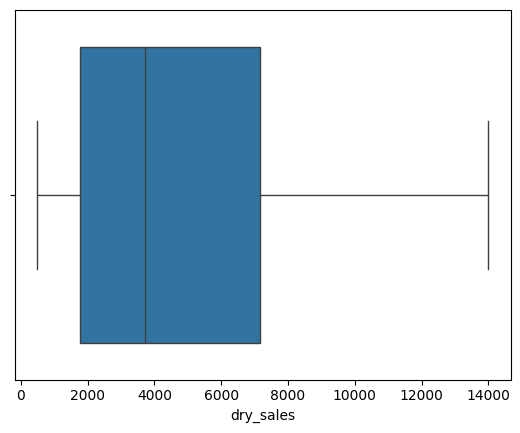

In [117]:
# box plot for the dry sales
sns.boxplot(x=train['dry_sales'])

In [118]:
train['luxury_sales'].max()

6999.65

Since the outlet city is a categorical variable - label encoding is used to present this data in a numeric format so that machine learning algorithms can process this data more effectively.

In [119]:
# import label encoder from sklearn
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [120]:
# fit encoder to outlet_city
encoder.fit(train['outlet_city'])

LabelEncoder()

In [121]:
# create encoded outlet city column
train['outlet_city_encoded'] = encoder.transform(train['outlet_city'])

In [122]:
train

,Customer_ID,outlet_city,luxury_sales,fresh_sales,dry_sales,cluster_catgeory,outlet_city_encoded
0,10493832.0,Kelaniya,1209.60,756.00,5292.00,4,11
1,10178643.0,Moratuwa,1590.12,1060.08,6007.12,1,13
2,10513916.0,Wattala,2288.88,1481.04,9155.52,4,19
3,10334589.0,Wattala,2274.94,1739.66,9099.76,4,19
4,10458365.0,Kelaniya,2345.49,2069.55,9243.99,4,11
...,...,...,...,...,...,...,...
774150,10197979.0,Gampaha,3893.40,3893.40,3448.44,3,4
774151,10494575.0,Katunayake,6095.86,5557.99,6275.15,3,10
774152,10565682.0,Colombo,5121.42,4820.16,4669.53,3,1
774153,10351977.0,Kandy,6311.76,6311.76,5940.48,3,9


In [123]:
train.dtypes

,0
Customer_ID,object
outlet_city,object
luxury_sales,float64
fresh_sales,float64
dry_sales,float64
cluster_catgeory,object
outlet_city_encoded,int64


In [124]:
# Change outlet city encoded to object data type
train['outlet_city_encoded'] = train['outlet_city_encoded'].astype(object)

In [125]:
train.dtypes

,0
Customer_ID,object
outlet_city,object
luxury_sales,float64
fresh_sales,float64
dry_sales,float64
cluster_catgeory,object
outlet_city_encoded,object


## **EDA After Cleaning**

### Univariate

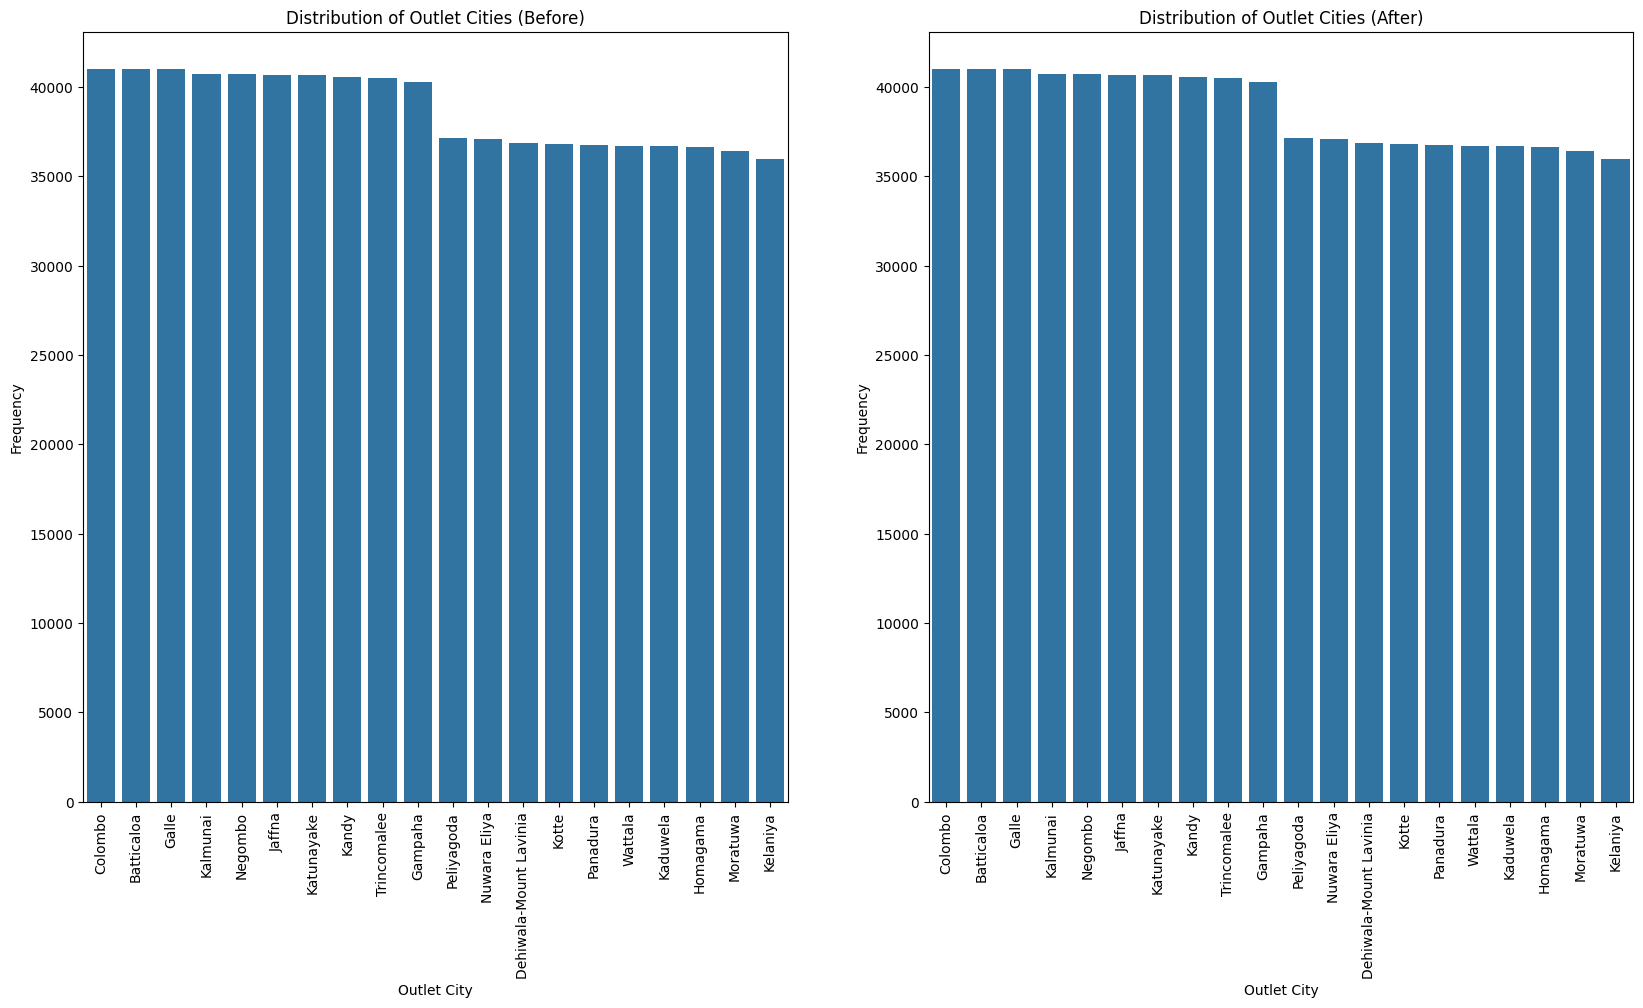

In [167]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

sns.countplot(x='outlet_city', data=train_before, order=train_before['outlet_city'].value_counts().index, ax=axes[0])
axes[0].set_title('Distribution of Outlet Cities (Before)')
axes[0].set_xlabel('Outlet City')
axes[0].set_ylabel('Frequency')
axes[0].tick_params(axis='x', rotation=90)

sns.countplot(x='outlet_city', data=train, order=train['outlet_city'].value_counts().index, ax=axes[1])
axes[1].set_title('Distribution of Outlet Cities (After)')
axes[1].set_xlabel('Outlet City')
axes[1].set_ylabel('Frequency')
axes[1].tick_params(axis='x', rotation=90)

plt.show()

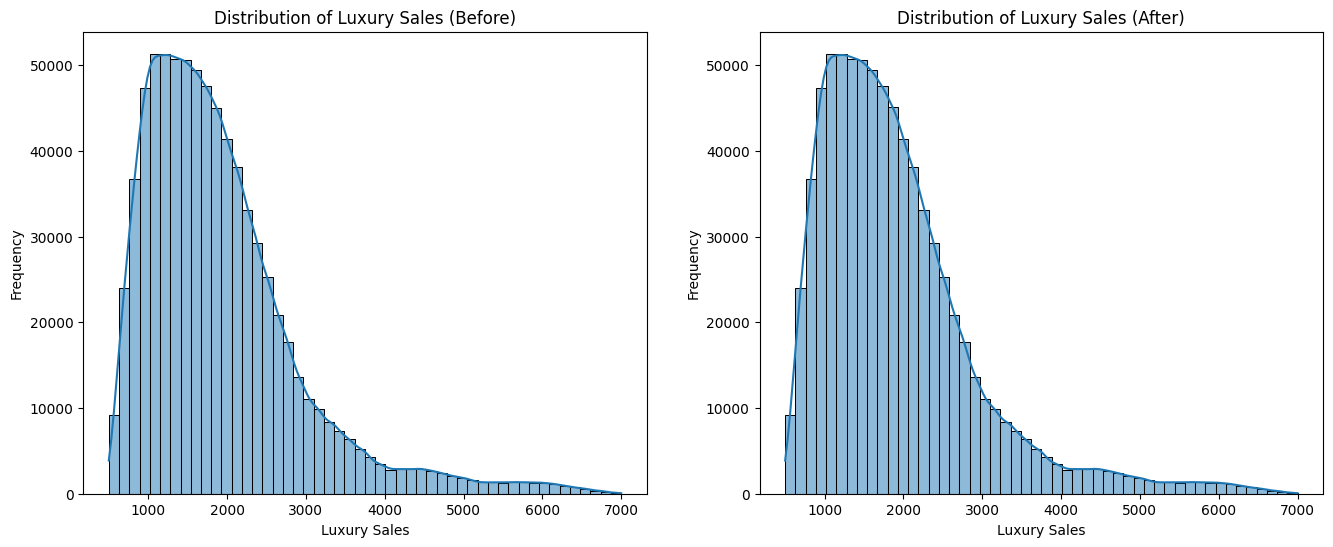

In [166]:
train_before['luxury_sales'] = pd.to_numeric(train_before['luxury_sales'], errors='coerce').astype(float)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(train_before["luxury_sales"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Luxury Sales (Before)")
axes[0].set_xlabel("Luxury Sales")
axes[0].set_ylabel("Frequency")

sns.histplot(train["luxury_sales"], bins=50, kde=True, ax=axes[1])
axes[1].set_title("Distribution of Luxury Sales (After)")
axes[1].set_xlabel("Luxury Sales")
axes[1].set_ylabel("Frequency")

plt.show()

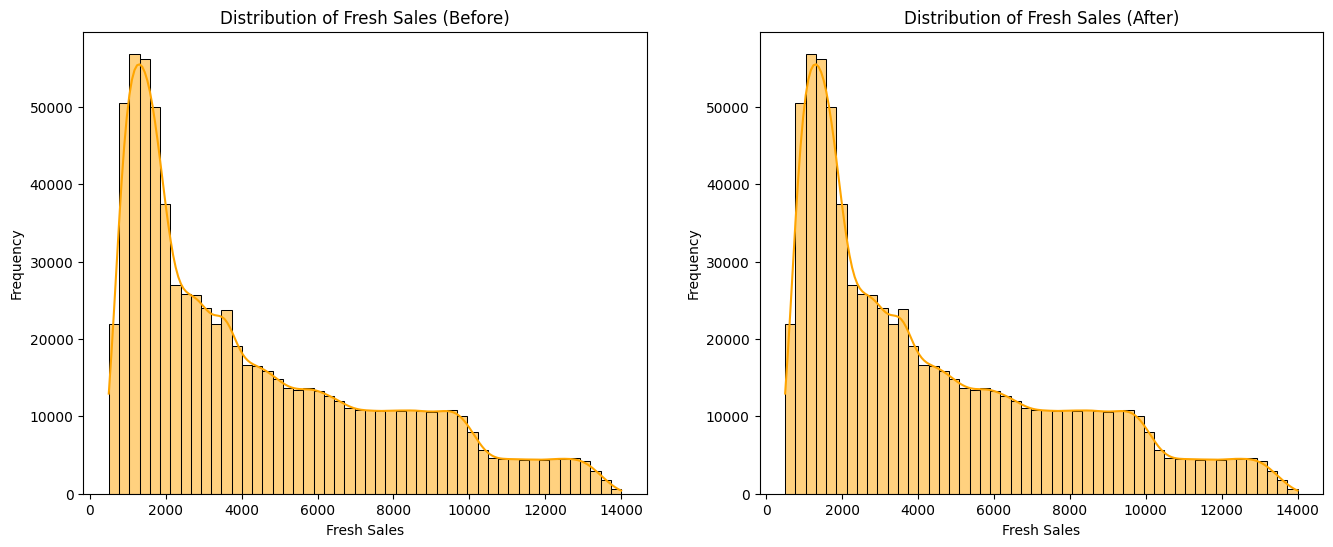

In [151]:
train_before['fresh_sales'] = pd.to_numeric(train_before['fresh_sales'], errors='coerce').astype(float)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(train_before['fresh_sales'], bins=50, kde=True, color='orange', ax=axes[0])
axes[0].set_title("Distribution of Fresh Sales (Before)")
axes[0].set_xlabel("Fresh Sales")
axes[0].set_ylabel("Frequency")

sns.histplot(train['fresh_sales'], bins=50, kde=True, color='orange', ax=axes[1])
axes[1].set_title("Distribution of Fresh Sales (After)")
axes[1].set_xlabel("Fresh Sales")
axes[1].set_ylabel("Frequency")

plt.show()

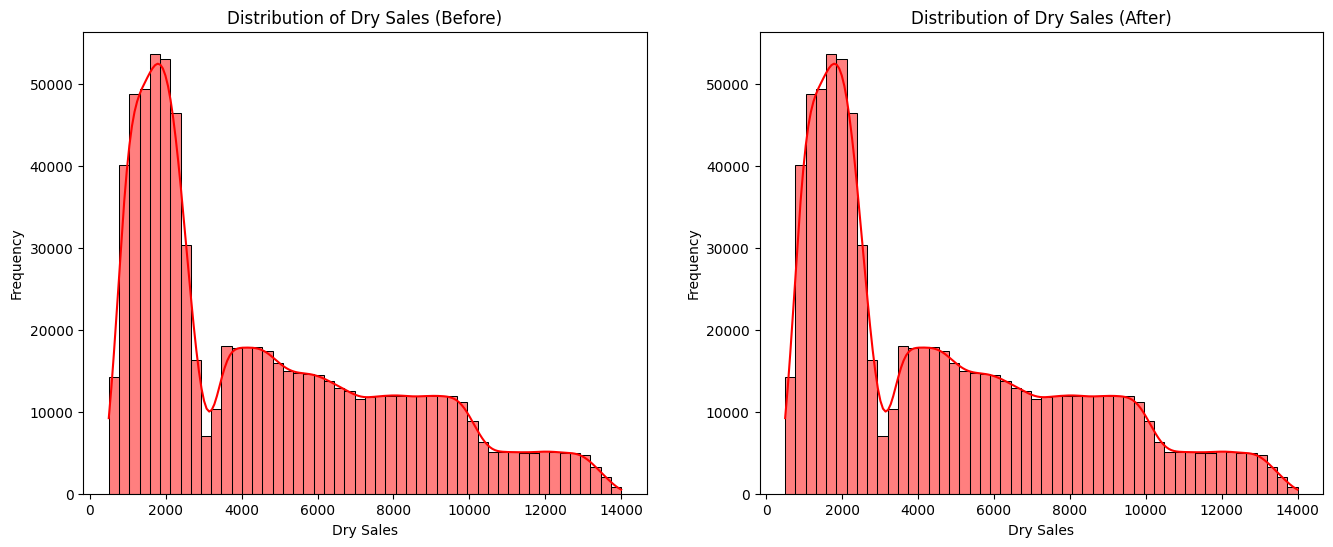

In [152]:
train_before['dry_sales'] = pd.to_numeric(train_before['dry_sales'], errors='coerce').astype(float)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(train_before['dry_sales'], bins=50, kde=True, color='red', ax=axes[0])
axes[0].set_title("Distribution of Dry Sales (Before)")
axes[0].set_xlabel("Dry Sales")
axes[0].set_ylabel("Frequency")

sns.histplot(train['dry_sales'], bins=50, kde=True, color='red', ax=axes[1])
axes[1].set_title("Distribution of Dry Sales (After)")
axes[1].set_xlabel("Dry Sales")
axes[1].set_ylabel("Frequency")

plt.show()

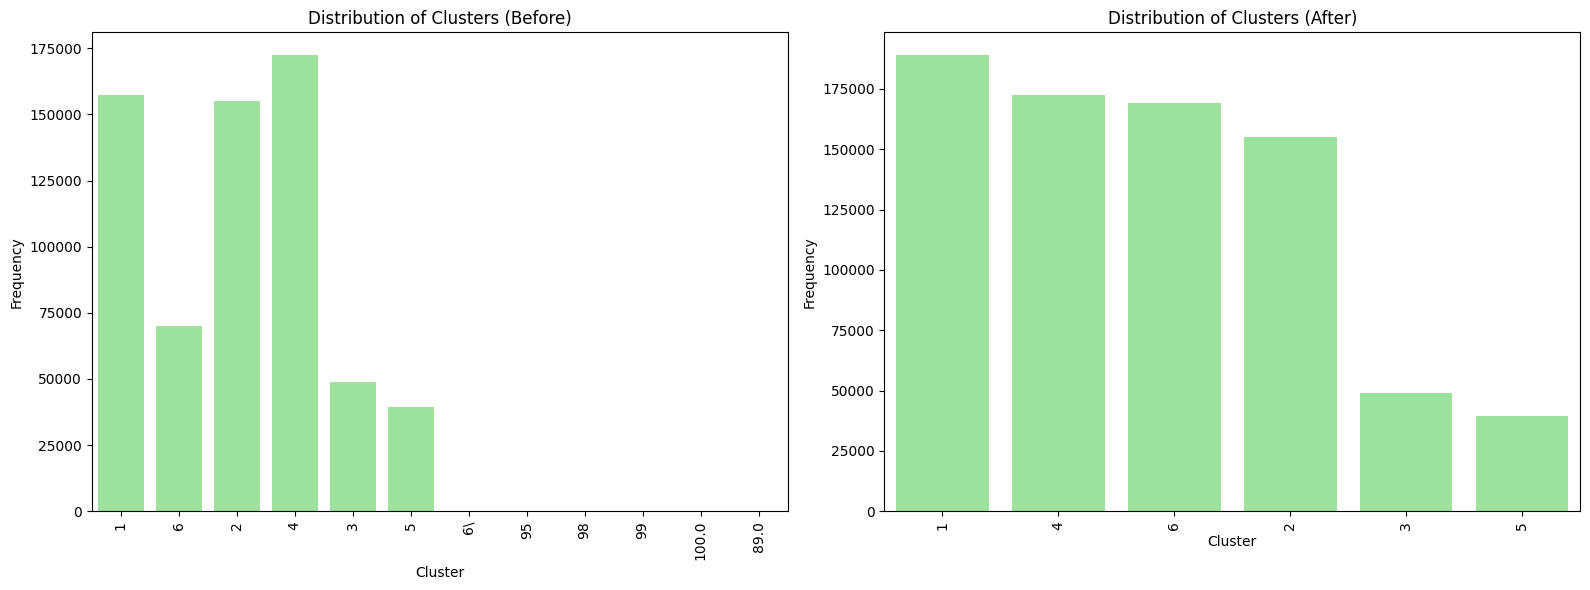

In [155]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(x='cluster_catgeory', data=train_before, order=train_before['cluster_catgeory'].value_counts().index, color='lightgreen', ax=axes[0])
axes[0].set_title('Distribution of Clusters (Before)')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Frequency')
axes[0].tick_params(axis='x', rotation=90)

sns.countplot(x='cluster_catgeory', data=train, order=train['cluster_catgeory'].value_counts().index, color='lightgreen', ax=axes[1])  # Use train for after cleaning
axes[1].set_title('Distribution of Clusters (After)')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Frequency')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

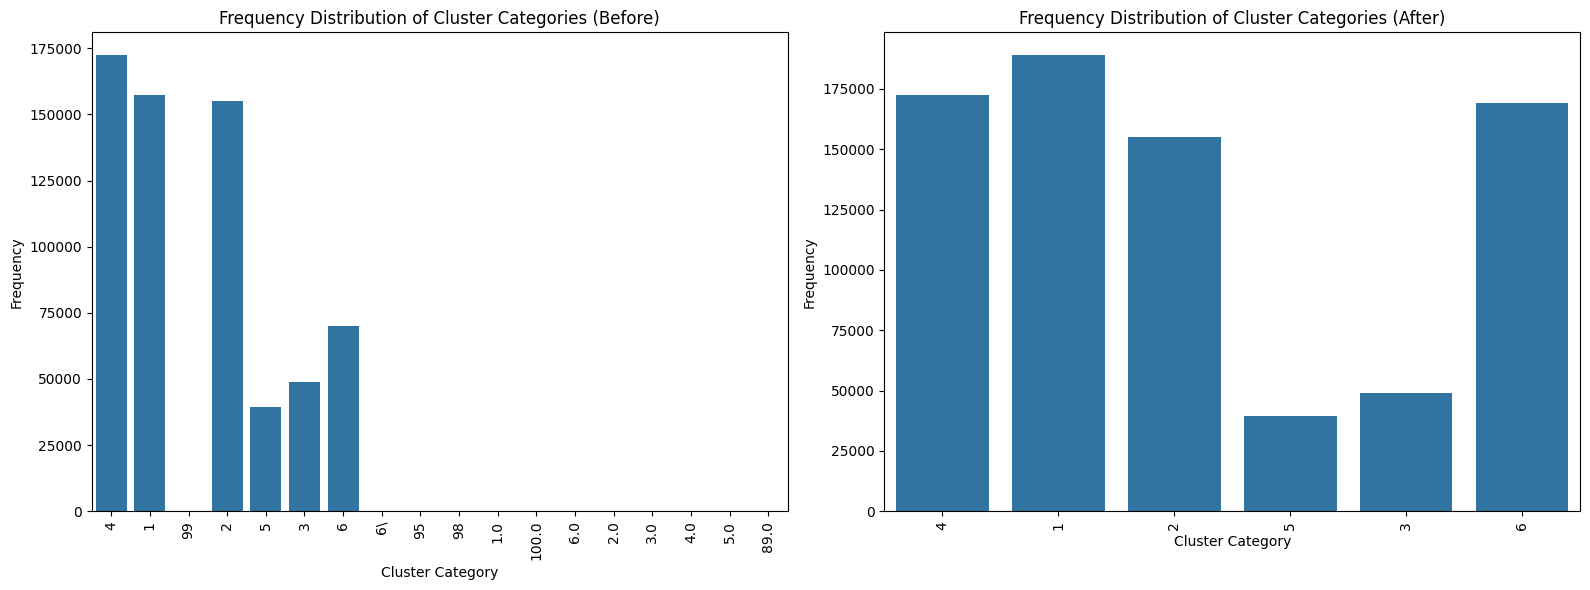

In [157]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))


sns.countplot(x='cluster_catgeory', data=train_before, ax=axes[0])
axes[0].set_title("Frequency Distribution of Cluster Categories (Before)")
axes[0].set_xlabel("Cluster Category")
axes[0].set_ylabel("Frequency")
axes[0].tick_params(axis='x', rotation=90)


sns.countplot(x='cluster_catgeory', data=train, ax=axes[1])
axes[1].set_title("Frequency Distribution of Cluster Categories (After)")
axes[1].set_xlabel("Cluster Category")
axes[1].set_ylabel("Frequency")
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

### Multivariate

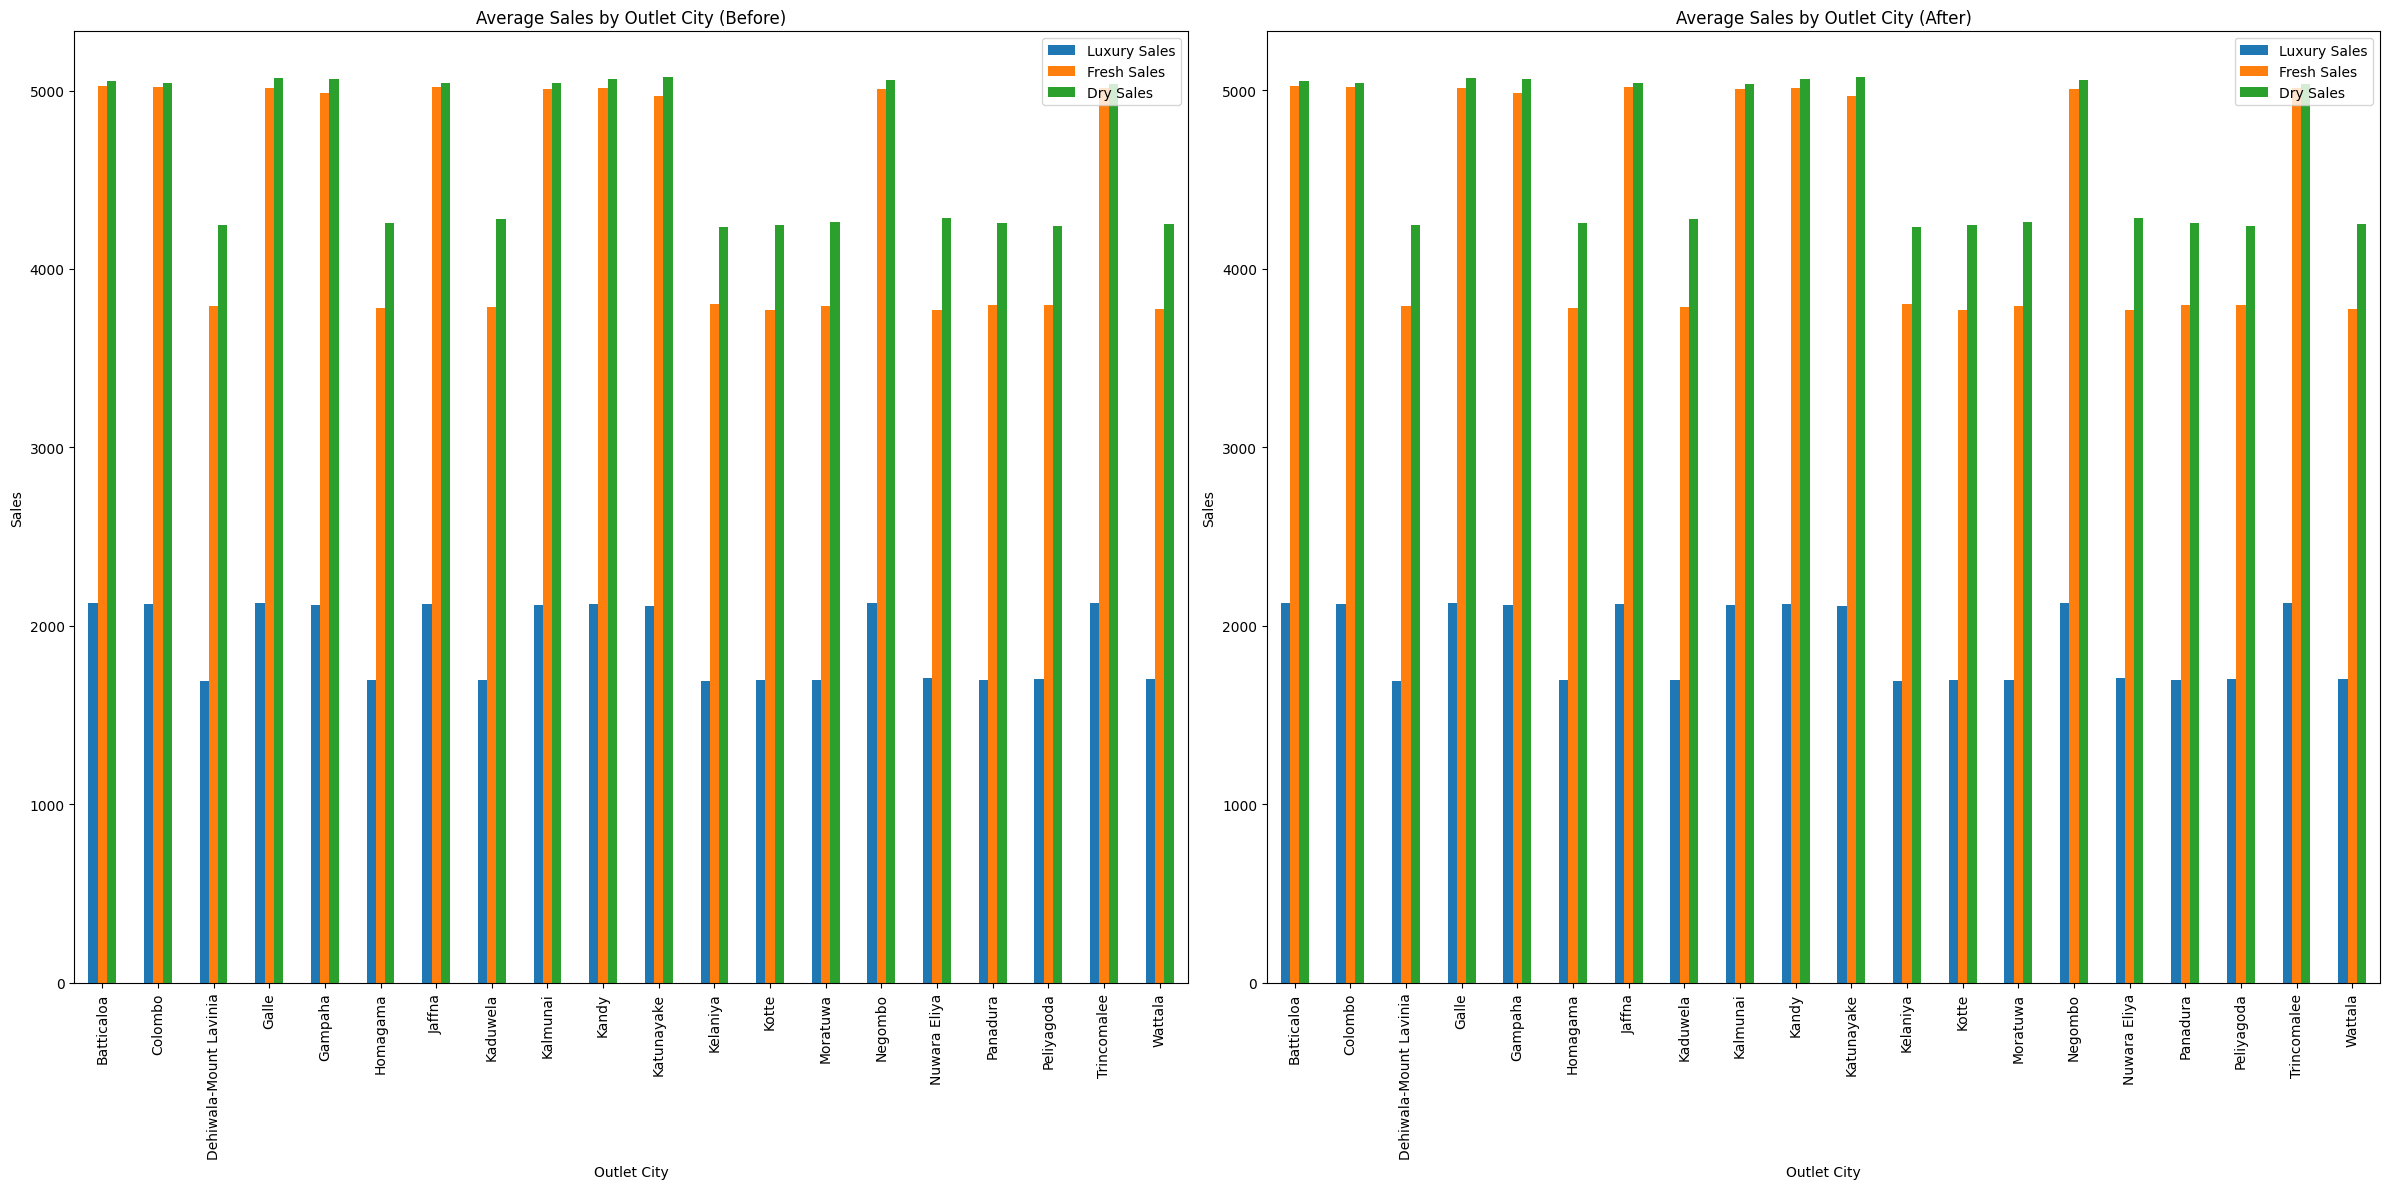

In [158]:
train_grouped_before = train_before.groupby("outlet_city")[["luxury_sales", "fresh_sales", "dry_sales"]].mean(numeric_only=True).reset_index()

train_grouped_after = train.groupby("outlet_city")[["luxury_sales", "fresh_sales", "dry_sales"]].mean(numeric_only=True).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(24, 12))

train_grouped_before.plot(x="outlet_city", kind="bar", ax=axes[0])
axes[0].set_title("Average Sales by Outlet City (Before)")
axes[0].set_xlabel("Outlet City")
axes[0].set_ylabel("Sales")
axes[0].tick_params(axis='x', rotation=90)
axes[0].legend(["Luxury Sales", "Fresh Sales", "Dry Sales"])

train_grouped_after.plot(x="outlet_city", kind="bar", ax=axes[1])
axes[1].set_title("Average Sales by Outlet City (After)")
axes[1].set_xlabel("Outlet City")
axes[1].set_ylabel("Sales")
axes[1].tick_params(axis='x', rotation=90)
axes[1].legend(["Luxury Sales", "Fresh Sales", "Dry Sales"])

plt.tight_layout()
plt.show()

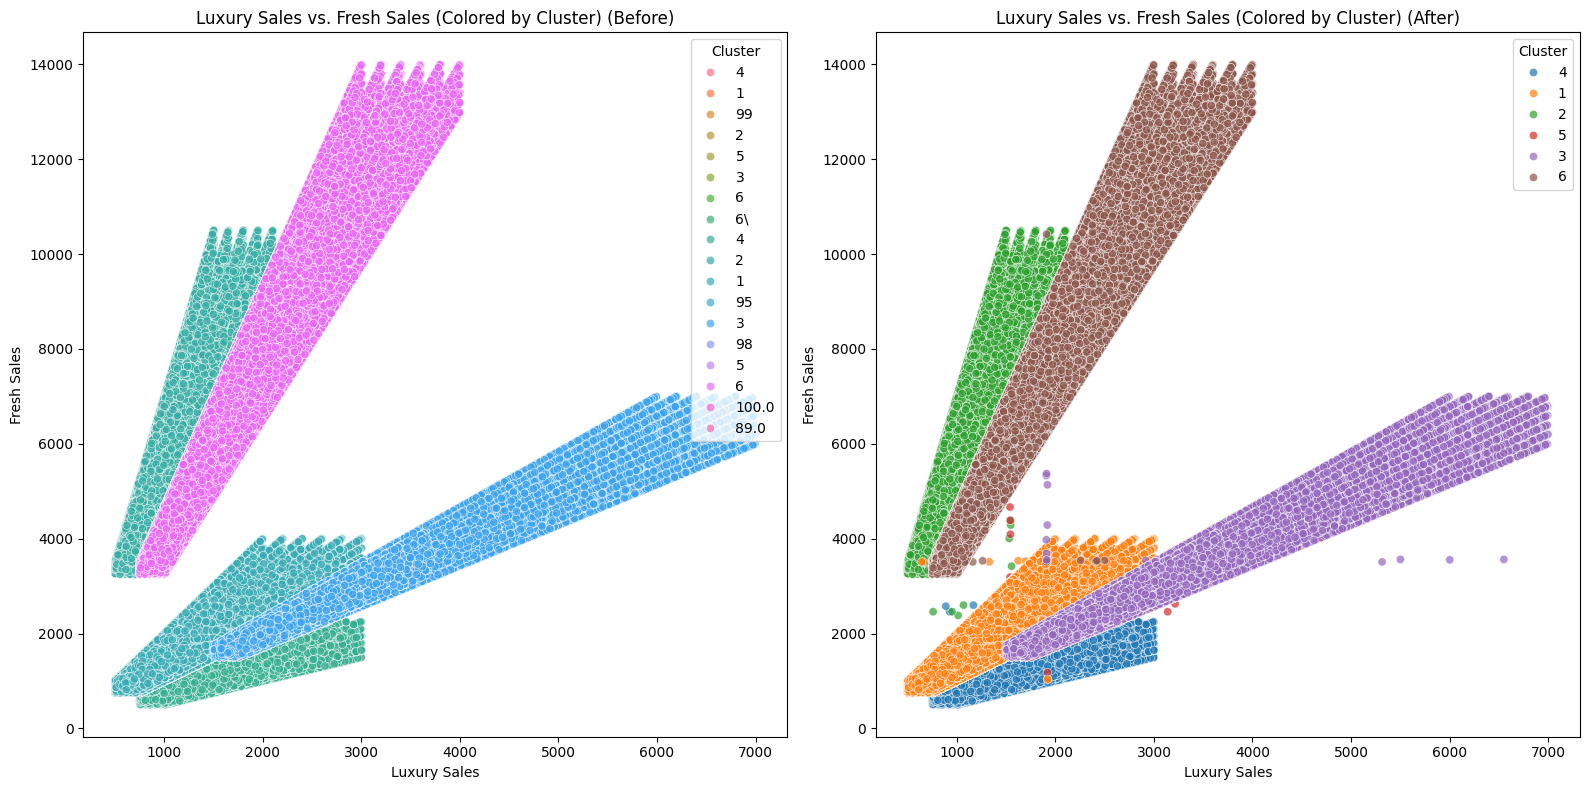

In [159]:
plt.figure(figsize=(16, 8))


plt.subplot(1, 2, 1)
sns.scatterplot(data=train_before, x="luxury_sales", y="fresh_sales", hue="cluster_catgeory", alpha=0.7)
plt.title("Luxury Sales vs. Fresh Sales (Colored by Cluster) (Before)")
plt.xlabel("Luxury Sales")
plt.ylabel("Fresh Sales")
plt.legend(title="Cluster")


plt.subplot(1, 2, 2)
sns.scatterplot(data=train, x="luxury_sales", y="fresh_sales", hue="cluster_catgeory", alpha=0.7)
plt.title("Luxury Sales vs. Fresh Sales (Colored by Cluster) (After)")
plt.xlabel("Luxury Sales")
plt.ylabel("Fresh Sales")
plt.legend(title="Cluster")

plt.tight_layout()
plt.show()

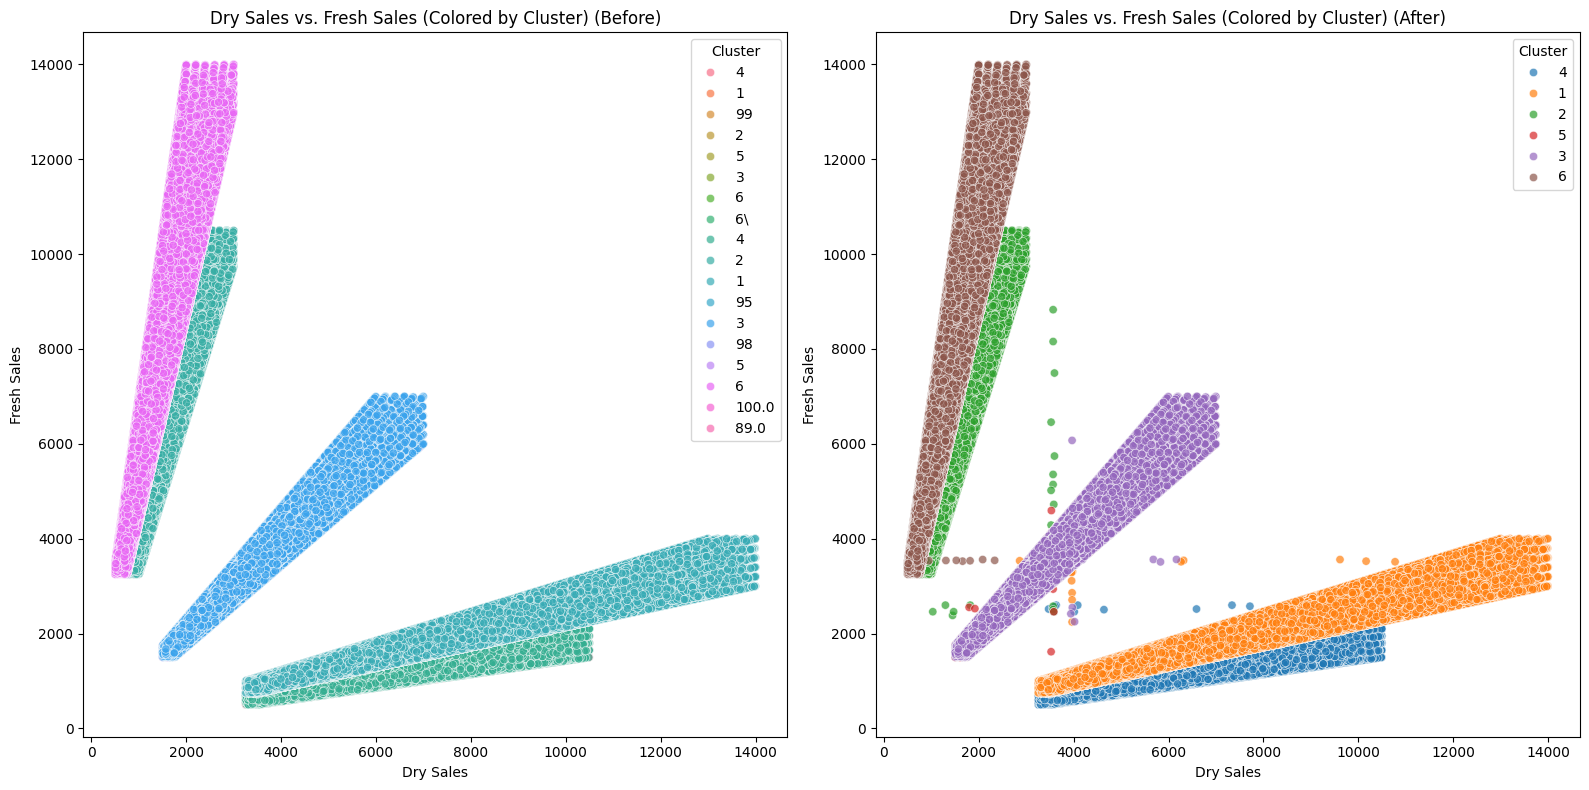

In [160]:
plt.figure(figsize=(16, 8))


plt.subplot(1, 2, 1)
sns.scatterplot(data=train_before, x="dry_sales", y="fresh_sales", hue="cluster_catgeory", alpha=0.7)
plt.title("Dry Sales vs. Fresh Sales (Colored by Cluster) (Before)")
plt.xlabel("Dry Sales")
plt.ylabel("Fresh Sales")
plt.legend(title="Cluster")


plt.subplot(1, 2, 2)
sns.scatterplot(data=train, x="dry_sales", y="fresh_sales", hue="cluster_catgeory", alpha=0.7)
plt.title("Dry Sales vs. Fresh Sales (Colored by Cluster) (After)")
plt.xlabel("Dry Sales")
plt.ylabel("Fresh Sales")
plt.legend(title="Cluster")

plt.tight_layout()
plt.show()

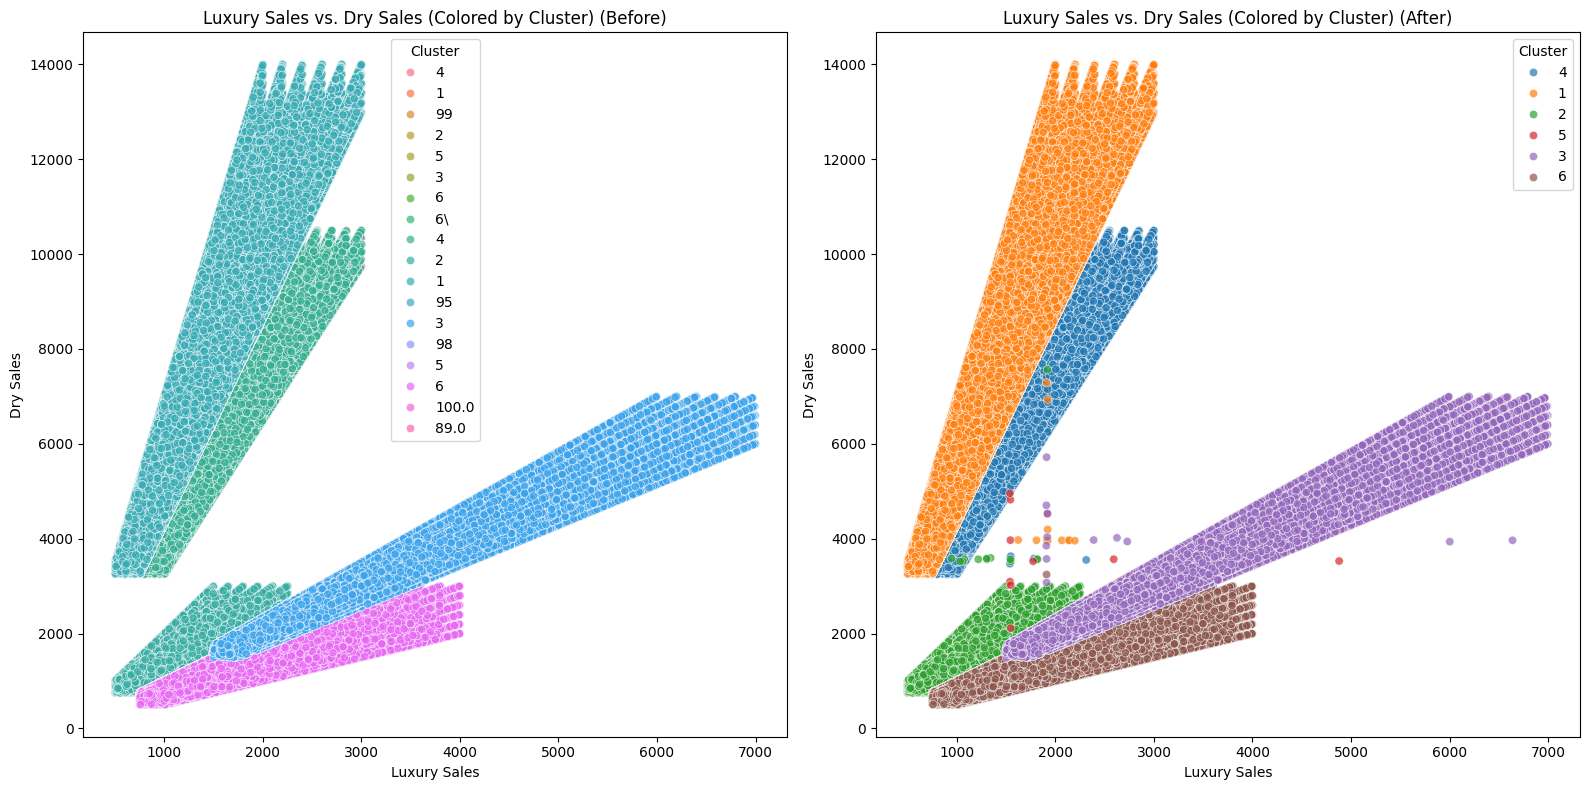

In [161]:
plt.figure(figsize=(16, 8))


plt.subplot(1, 2, 1)  # Change subplot arrangement to 1 row, 2 columns
sns.scatterplot(data=train_before, x="luxury_sales", y="dry_sales", hue="cluster_catgeory", alpha=0.7)
plt.legend(title="Cluster")
plt.title("Luxury Sales vs. Dry Sales (Colored by Cluster) (Before)")
plt.xlabel("Luxury Sales")
plt.ylabel("Dry Sales")


plt.subplot(1, 2, 2)
sns.scatterplot(data=train, x="luxury_sales", y="dry_sales", hue="cluster_catgeory", alpha=0.7)
plt.legend(title="Cluster")
plt.title("Luxury Sales vs. Dry Sales (Colored by Cluster) (After)")
plt.xlabel("Luxury Sales")
plt.ylabel("Dry Sales")

plt.tight_layout()
plt.show()

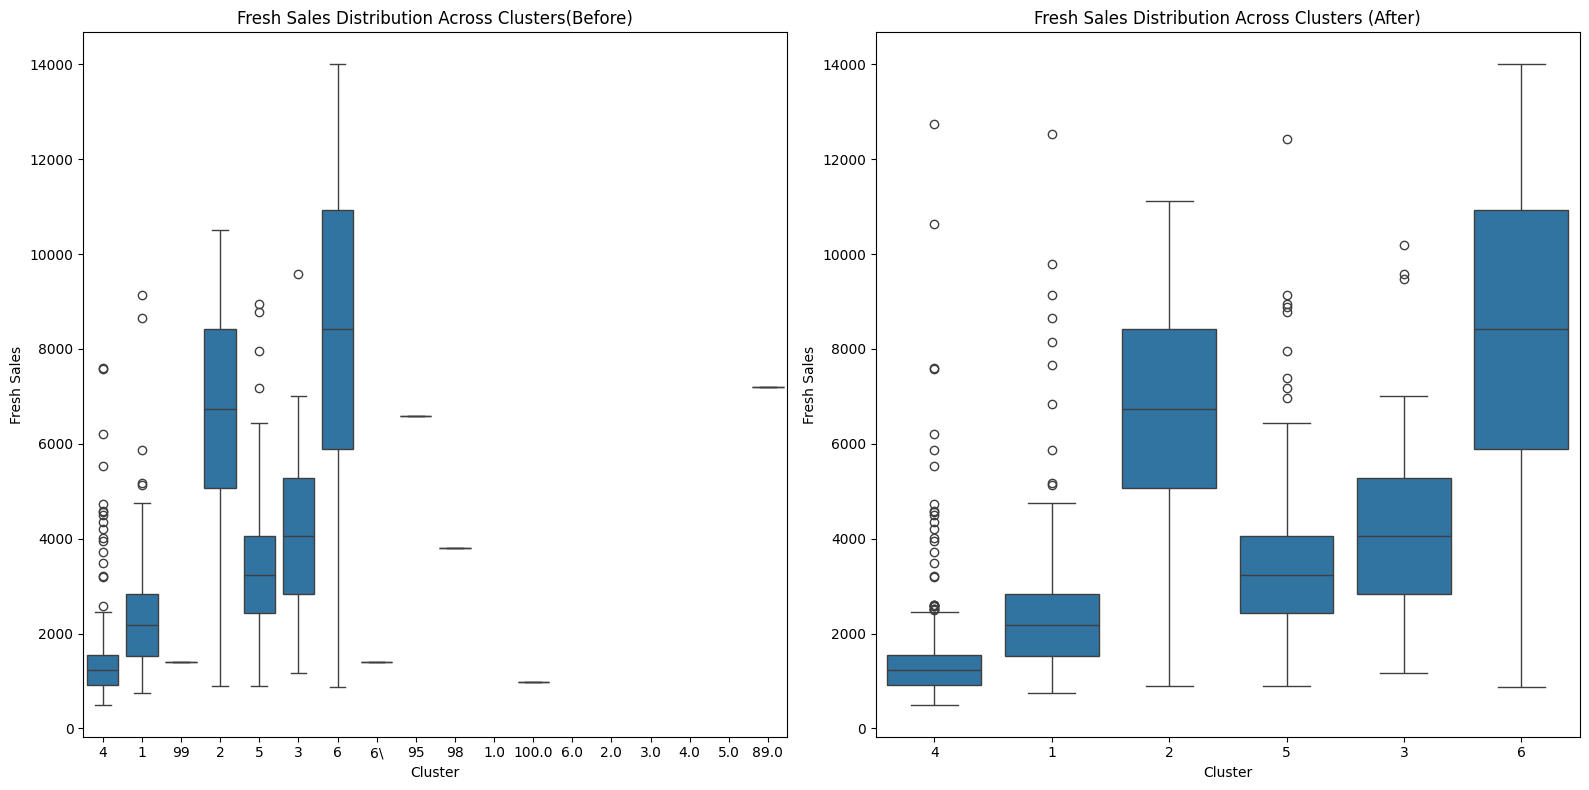

In [162]:
plt.figure(figsize=(16, 8))


plt.subplot(1, 2, 1)
sns.boxplot(data=train_before, x="cluster_catgeory", y="fresh_sales")
plt.title("Fresh Sales Distribution Across Clusters(Before)")
plt.xlabel("Cluster")
plt.ylabel("Fresh Sales")


plt.subplot(1, 2, 2)
sns.boxplot(data=train, x="cluster_catgeory", y="fresh_sales")
plt.title("Fresh Sales Distribution Across Clusters (After)")
plt.xlabel("Cluster")
plt.ylabel("Fresh Sales")

plt.tight_layout()
plt.show()

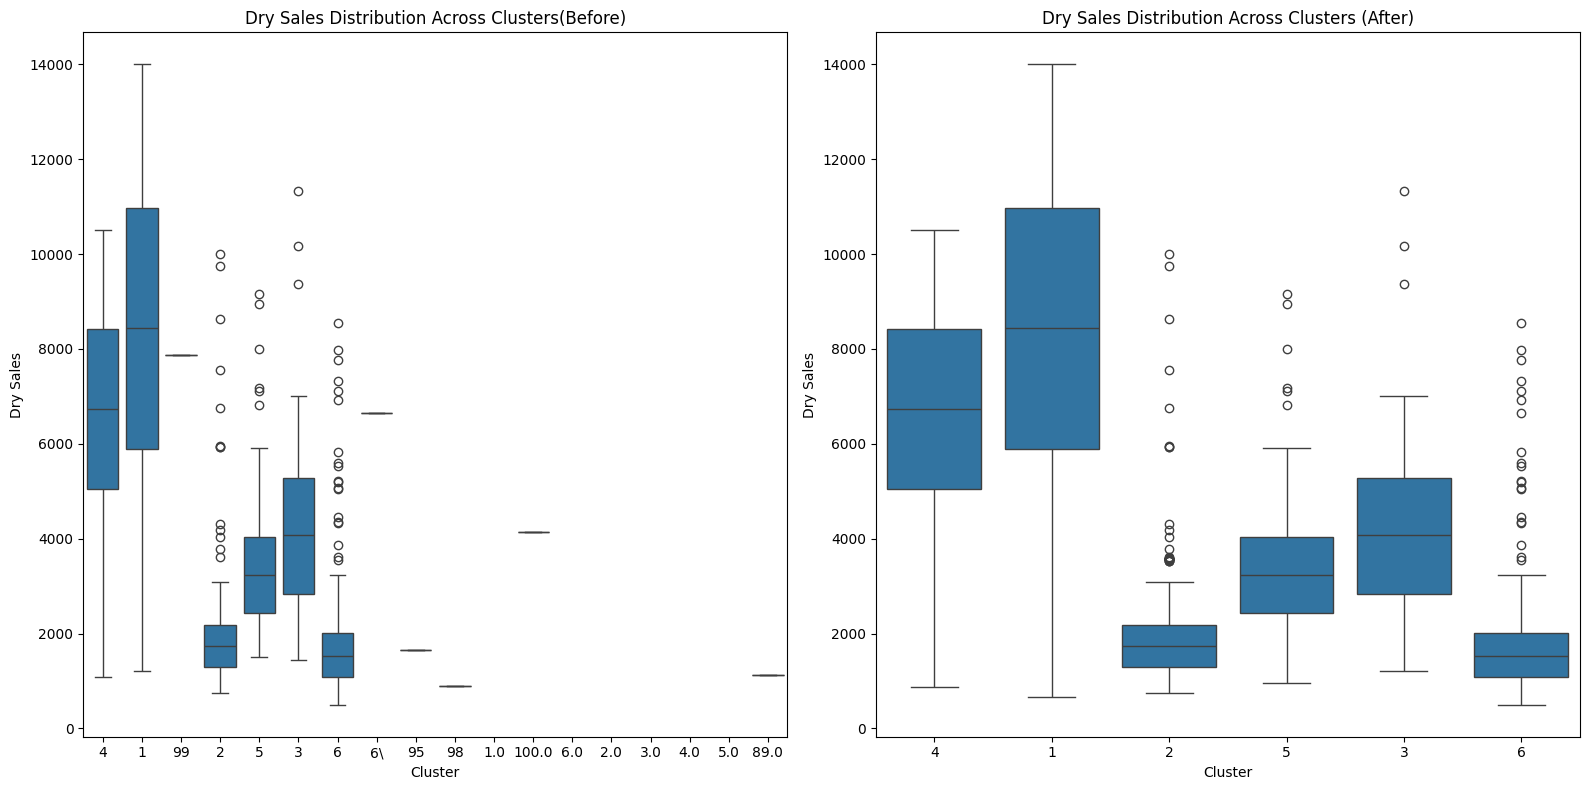

In [163]:
plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
sns.boxplot(data=train_before, x="cluster_catgeory", y="dry_sales")
plt.title("Dry Sales Distribution Across Clusters(Before)")
plt.xlabel("Cluster")
plt.ylabel("Dry Sales")

plt.subplot(1, 2, 2)
sns.boxplot(data=train, x="cluster_catgeory", y="dry_sales")
plt.title("Dry Sales Distribution Across Clusters (After)")
plt.xlabel("Cluster")
plt.ylabel("Dry Sales")

plt.tight_layout()
plt.show()

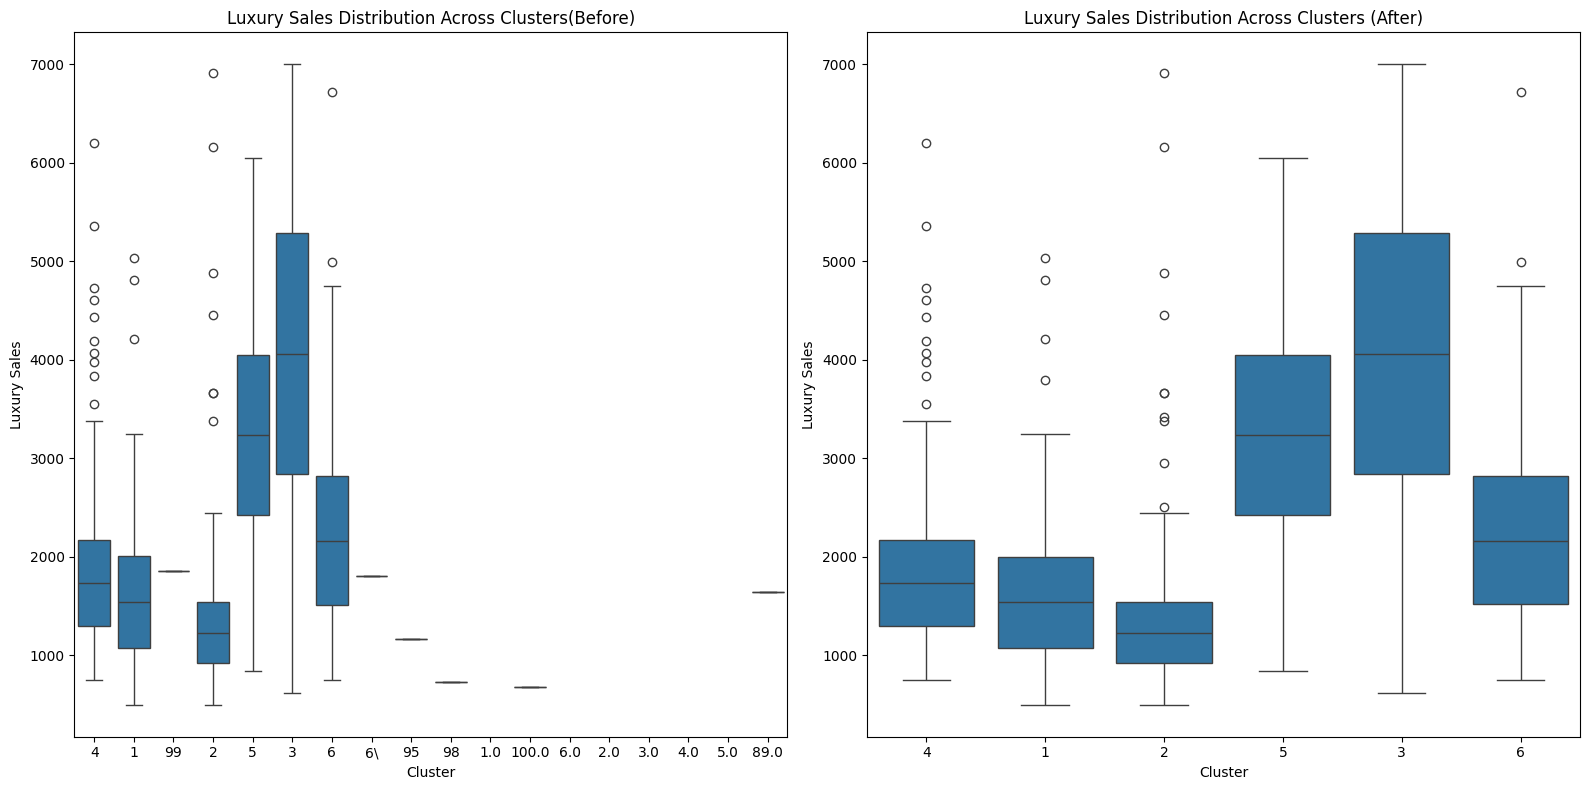

In [164]:
plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
sns.boxplot(data=train_before, x="cluster_catgeory", y="luxury_sales")
plt.title("Luxury Sales Distribution Across Clusters(Before)")
plt.xlabel("Cluster")
plt.ylabel("Luxury Sales")

plt.subplot(1, 2, 2)
sns.boxplot(data=train, x="cluster_catgeory", y="luxury_sales")
plt.title("Luxury Sales Distribution Across Clusters (After)")
plt.xlabel("Cluster")
plt.ylabel("Luxury Sales")

plt.tight_layout()
plt.show()

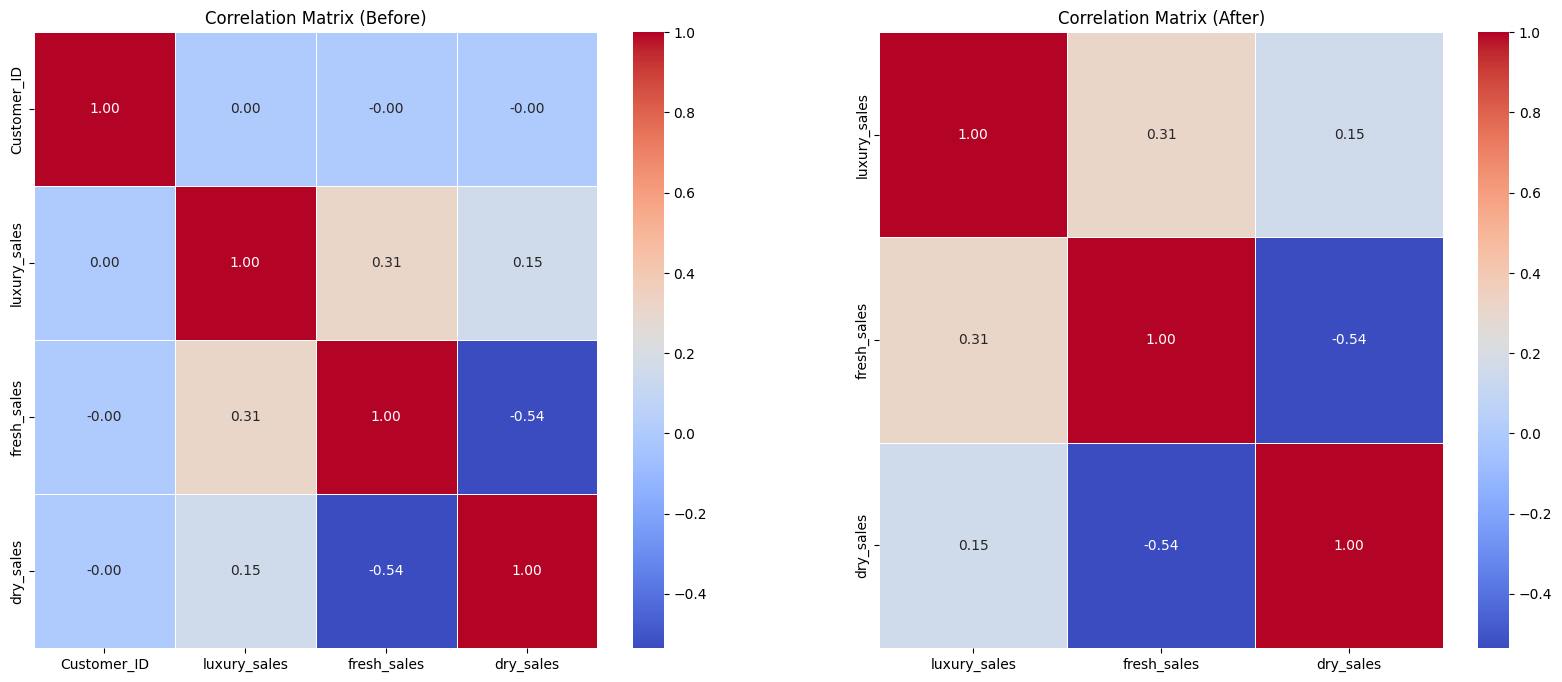

In [165]:
correlation_matrix_before = train_before.select_dtypes(include=np.number).corr()
correlation_matrix_after = train.select_dtypes(include=np.number).corr()

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(correlation_matrix_before, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, ax=axes[0])
axes[0].set_title('Correlation Matrix (Before)')

sns.heatmap(correlation_matrix_after, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, ax=axes[1])
axes[1].set_title('Correlation Matrix (After)')

plt.show()

#**Exporting clean data**


In [140]:
from google.colab import auth
from googleapiclient.discovery import build
from googleapiclient.http import MediaFileUpload

# Authenticate Google Drive access
auth.authenticate_user()
drive_service = build('drive', 'v3')

# Define Google Drive folder ID (Replace with your actual folder ID)
folder_id = "1XkRUF4MCrgqzis3v2C7Bx9GQaK5XgFZI"

# Define the CSV file name
file_name = "clean_train.csv"

# Search for the file inside the folder
query = f"'{folder_id}' in parents and name='{file_name}'"
results = drive_service.files().list(q=query, fields="files(id)").execute()
files = results.get("files", [])

# If file exists, delete it before uploading the new one
if files:
    file_id = files[0]['id']
    drive_service.files().delete(fileId=file_id).execute()

# Save DataFrame as CSV locally
local_path = f"/content/{file_name}"
train.to_csv(local_path, index=False)

# Upload the new file
file_metadata = {"name": file_name, "parents": [folder_id]}
media = MediaFileUpload(local_path, mimetype="text/csv")

uploaded_file = drive_service.files().create(
    body=file_metadata, media_body=media, fields="id"
).execute()

print(f"File '{file_name}' uploaded successfully!")

File 'clean_train.csv' uploaded successfully!


In [141]:
train

,Customer_ID,outlet_city,luxury_sales,fresh_sales,dry_sales,cluster_catgeory,outlet_city_encoded
0,10493832.0,Kelaniya,1209.60,756.00,5292.00,4,11
1,10178643.0,Moratuwa,1590.12,1060.08,6007.12,1,13
2,10513916.0,Wattala,2288.88,1481.04,9155.52,4,19
3,10334589.0,Wattala,2274.94,1739.66,9099.76,4,19
4,10458365.0,Kelaniya,2345.49,2069.55,9243.99,4,11
...,...,...,...,...,...,...,...
774150,10197979.0,Gampaha,3893.40,3893.40,3448.44,3,4
774151,10494575.0,Katunayake,6095.86,5557.99,6275.15,3,10
774152,10565682.0,Colombo,5121.42,4820.16,4669.53,3,1
774153,10351977.0,Kandy,6311.76,6311.76,5940.48,3,9
